In [1]:
# CORE LIBRARIES
import pandas as pd
import numpy as np

# VISUALIZATION LIBRARIES
import matplotlib.pyplot as plt
import seaborn as sns

# MODELLING
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# SETTINGS
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

In [2]:
# Load data
url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"

df = pd.read_csv(url)

In [3]:
# First look at the data
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Shape: 1470 rows × 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# ── Column names and data types ───────────────────────────────────────
print(df.dtypes)

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [5]:
# ── See unique values for each column ─────────────────────────────────
for col in df.columns:
    print(f"{col:35s} → {df[col].nunique():4d} unique values   |   Sample: {df[col].unique()[:4]}")

Age                                 →   43 unique values   |   Sample: [41 49 37 33]
Attrition                           →    2 unique values   |   Sample: ['Yes' 'No']
BusinessTravel                      →    3 unique values   |   Sample: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
DailyRate                           →  886 unique values   |   Sample: [1102  279 1373 1392]
Department                          →    3 unique values   |   Sample: ['Sales' 'Research & Development' 'Human Resources']
DistanceFromHome                    →   29 unique values   |   Sample: [1 8 2 3]
Education                           →    5 unique values   |   Sample: [2 1 4 3]
EducationField                      →    6 unique values   |   Sample: ['Life Sciences' 'Other' 'Medical' 'Marketing']
EmployeeCount                       →    1 unique values   |   Sample: [1]
EmployeeNumber                      → 1470 unique values   |   Sample: [1 2 4 5]
EnvironmentSatisfaction             →    4 unique value

## Data Quality Checks
Before analysing anything we need to check if the data has any problems 
that could corrupt our analysis or mislead our model.

We are checking for:
- **Missing values** — empty cells that need to be handled
- **Duplicate rows** — repeated records that would bias our analysis
- **Constant columns** — columns where every row has the same value
- **Data types** — are columns stored as the correct type
- **Impossible values** — values that make no logical sense
- **Cardinality** — how many unique values each column has
- **Identifier columns** — ID columns that must be excluded from modeling

In [7]:
# ── Missing values ────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing values: {missing.sum()}")

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total missing values: 0


### Finding
No missing values were found across all 35 columns and 1,470 rows.

### Implication
This is unusually clean data. In real HR datasets fields like performance 
scores, salary bands, and exit interview responses are frequently 
incomplete. This dataset has clearly been pre-cleaned by IBM for 
demonstration purposes.

### Action
No imputation required.

In [9]:
# ── Duplicate rows ────────────────────────────────────────────────────
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

Duplicate rows: 0


### Finding
No duplicate rows were found across all 1,470 records.

### Implication
Every row represents a unique employee. Our analysis will not be 
biased by repeated records inflating the frequency of any particular 
employee profile.

### Action
No action required. We can proceed with all 1,470 rows intact.

In [11]:
# ── Constant columns ──────────────────────────────────────────────────
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Constant columns found: {constant_cols}")

Constant columns found: ['EmployeeCount', 'Over18', 'StandardHours']


### Finding
Three constant columns were identified:
- **EmployeeCount** — always = 1
- **Over18** — always = 'Y'
- **StandardHours** — always = 80

### Implication
These three columns carry absolutely no predictive information. 
Every single employee has the same value so the model cannot use 
them to differentiate between someone who leaves and someone who stays.

Including them would add noise to the model.

### Action
These three columns will be dropped during the preprocessing phase 
before model training.

In [13]:
# ── Data types ────────────────────────────────────────────────────────
print(df.dtypes.value_counts())
print(f"\nNumerical columns : {df.select_dtypes(include=['int64','float64']).shape[1]}")
print(f"Categorical columns: {df.select_dtypes(include='object').shape[1]}")

int64     26
object     9
Name: count, dtype: int64

Numerical columns : 26
Categorical columns: 9


In [14]:
# ── Impossible values ─────────────────────────────────────────────────
num_cols = df.select_dtypes(include=['int64','float64']).columns

print("Minimum values per numerical column:")
print(df[num_cols].min().sort_values())
print("\nMaximum values per numerical column:")
print(df[num_cols].max().sort_values(ascending=False))

Minimum values per numerical column:
YearsWithCurrManager           0
TrainingTimesLastYear          0
NumCompaniesWorked             0
YearsSinceLastPromotion        0
StockOptionLevel               0
YearsAtCompany                 0
TotalWorkingYears              0
YearsInCurrentRole             0
EmployeeNumber                 1
JobInvolvement                 1
EmployeeCount                  1
JobSatisfaction                1
WorkLifeBalance                1
Education                      1
DistanceFromHome               1
RelationshipSatisfaction       1
EnvironmentSatisfaction        1
JobLevel                       1
PerformanceRating              3
PercentSalaryHike             11
Age                           18
HourlyRate                    30
StandardHours                 80
DailyRate                    102
MonthlyIncome               1009
MonthlyRate                 2094
dtype: int64

Maximum values per numerical column:
MonthlyRate                 26999
MonthlyIncome       

### Finding
All numerical columns have values within logical and realistic ranges. 
No negative values were found in columns that should always be positive 
such as Age, MonthlyIncome and YearsAtCompany. Maximum values are 
all within believable human ranges.

### Implication
The data contains no impossible values that would corrupt our analysis 
or mislead our model.

### Action
No action required. The numerical columns are clean and ready for 
analysis.

In [16]:
# ── Cardinality check ─────────────────────────────────────────────────
cardinality = df.nunique().sort_values(ascending=False)
print("Unique values per column:")
print(cardinality)

Unique values per column:
EmployeeNumber              1470
MonthlyRate                 1427
MonthlyIncome               1349
DailyRate                    886
HourlyRate                    71
Age                           43
TotalWorkingYears             40
YearsAtCompany                37
DistanceFromHome              29
YearsInCurrentRole            19
YearsWithCurrManager          18
YearsSinceLastPromotion       16
PercentSalaryHike             15
NumCompaniesWorked            10
JobRole                        9
TrainingTimesLastYear          7
EducationField                 6
JobLevel                       5
Education                      5
StockOptionLevel               4
JobInvolvement                 4
JobSatisfaction                4
WorkLifeBalance                4
EnvironmentSatisfaction        4
RelationshipSatisfaction       4
BusinessTravel                 3
Department                     3
MaritalStatus                  3
PerformanceRating              2
OverTime         

### Finding
Two important patterns were identified:

**Identifier column:**
EmployeeNumber contains 1,470 unique values — one per row — 
confirming it is a pure ID column with no predictive value.

**Low cardinality integers (categorical in disguise):**
Nine columns are stored as integers but represent ordinal rating 
scales — JobLevel, Education, StockOptionLevel, JobInvolvement, 
JobSatisfaction, WorkLifeBalance, EnvironmentSatisfaction, 
RelationshipSatisfaction and PerformanceRating.

### Implication
Rating columns behave as ordered categories rather than true 
continuous numbers. EmployeeCount, Over18 and StandardHours 
appear again, confirming they are constants with no analytical value.

### Action
EmployeeNumber, EmployeeCount, Over18 and StandardHours will be 
dropped during preprocessing. Rating columns will be retained as 
integers for modeling and will be revisited during feature engineering.

In [18]:
# ── Identifier columns ────────────────────────────────────────────────
id_cols = [col for col in df.columns if df[col].nunique() == len(df)]
print(f"Identifier columns found: {id_cols}")
print("\nThese must be dropped before modeling")

Identifier columns found: ['EmployeeNumber']

These must be dropped before modeling


### Finding
EmployeeNumber is the only identifier column in the dataset.

### Implication
This column must never enter the model as it would cause data leakage, appearing as a strong predictor simply because it is unique per row.

### Action
EmployeeNumber will be added to our drop list alongside EmployeeCount, 
Over18 and StandardHours. All four columns will be removed during 
the preprocessing phase.

## Exploratory Data Analysis

### Target Variable Analysis

**Purpose:** Understand the distribution of the variable we are 
trying to predict — Attrition.

**Why it matters:** If 99% of employees stayed and only 1% left, 
a model that always predicts "stayed" would be 99% accurate but 
completely useless. We need to know how balanced our classes are 
before choosing our modeling strategy and evaluation metrics.

**What we are looking for:** The ratio between employees who left 
(Yes) and employees who stayed (No).

In [21]:
# ── Target variable distribution ──────────────────────────────────────
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print("Attrition Distribution:")
print(f"  No  (stayed) : {attrition_counts['No']:,}  ({attrition_pct['No']:.1f}%)")
print(f"  Yes (left)   : {attrition_counts['Yes']:,}  ({attrition_pct['Yes']:.1f}%)")
print(f"\nBaseline accuracy if we always predict No: {attrition_pct['No']:.1f}%")
print(f"Imbalance ratio: {attrition_counts['No'] / attrition_counts['Yes']:.1f}:1")

Attrition Distribution:
  No  (stayed) : 1,233  (83.9%)
  Yes (left)   : 237  (16.1%)

Baseline accuracy if we always predict No: 83.9%
Imbalance ratio: 5.2:1


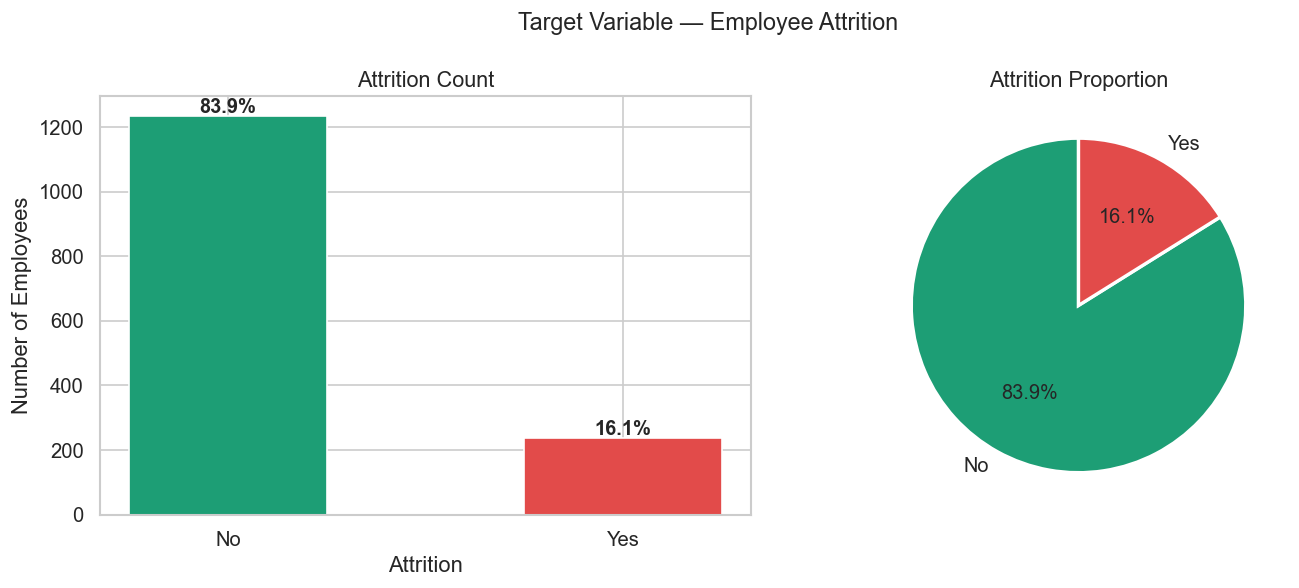

In [22]:
# ── Visualise target distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#1D9E75', '#E24B4A']
axes[0].bar(attrition_counts.index, attrition_counts.values,
            color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Attrition Count', fontsize=13)
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Number of Employees')
for i, (count, pct) in enumerate(zip(attrition_counts.values, 
                                      attrition_pct.values)):
    axes[0].text(i, count + 10, f'{pct:.1f}%', 
                ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(attrition_counts.values,
            labels=attrition_counts.index,
            colors=colors,
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[1].set_title('Attrition Proportion', fontsize=13)

plt.suptitle('Target Variable — Employee Attrition', fontsize=14)
plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()

### Finding
Of 1,470 employees, 1,233 stayed (83.9%) and 237 left (16.1%) 
giving an imbalance ratio of 5.2:1.

### Implication
The dataset is imbalanced. A naive model that always predicts 
"No" would achieve 83.9% accuracy while being completely useless 
at identifying employees at risk of leaving. This means raw accuracy 
is a misleading metric for this project.

Our primary evaluation metrics will therefore be:
- **ROC-AUC** — measures how well the model separates the two classes
- **Recall** — measures how many actual leavers the model catches
- **F1 Score** — balances precision and recall

### Action
We will use class_weight='balanced' when training our logistic 
regression model. This instructs the model to pay more attention 
to the minority class — employees who left — during training, 
compensating for the imbalance without artificially duplicating data.

### Numerical Variable Analysis

**Purpose:** Understand the distribution and spread of all 
numerical features in the dataset.

**Why it matters:** Understanding distributions tells us whether 
features are normally distributed or skewed, helps identify 
outliers, and informs decisions about transformations before 
modeling.

**What we are looking for:**
- Shape of each distribution — normal, skewed left or right
- Any features with extreme spread
- Features that look like they might need transformation

In [25]:
# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove columns we flagged for dropping
cols_to_remove = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
num_cols = [c for c in num_cols if c not in cols_to_remove]

print(f"Numerical columns to analyse: {len(num_cols)}")
print(num_cols)

Numerical columns to analyse: 23
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


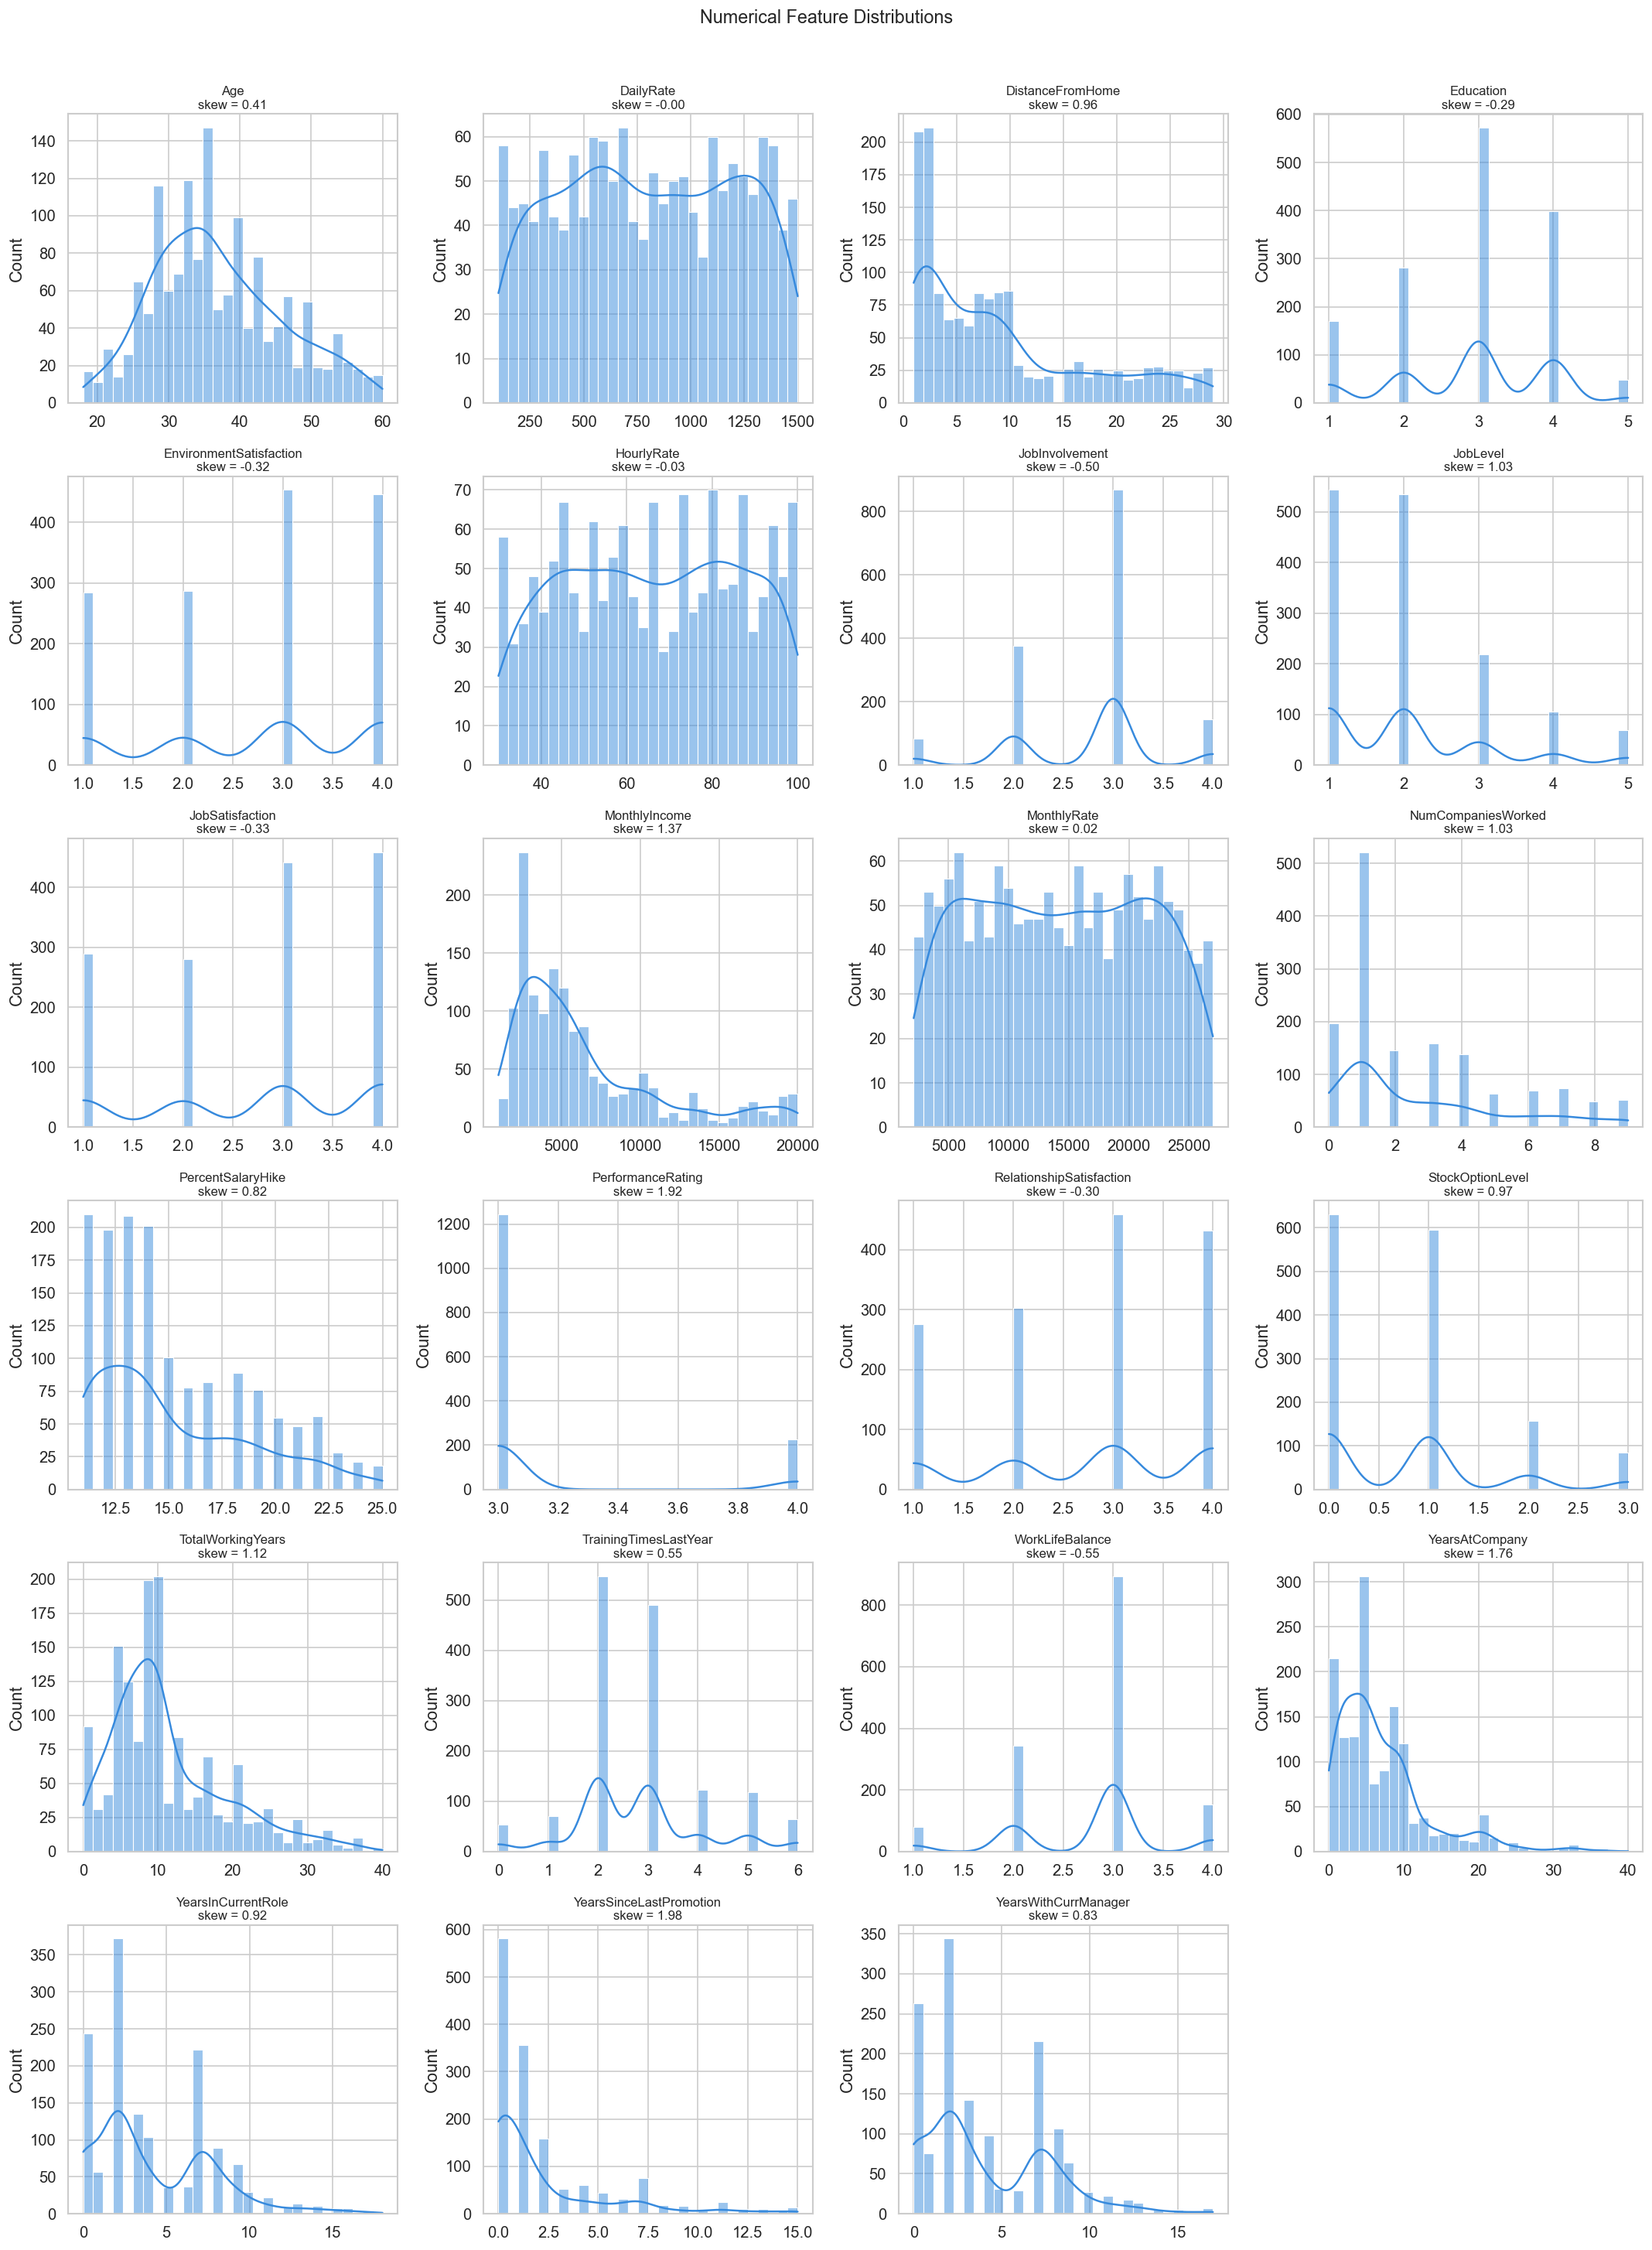

In [26]:
# Distribution plots for all numerical columns
n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    skew = df[col].skew()
    sns.histplot(df[col], kde=True, ax=ax, color='#378ADD', bins=30)
    ax.set_title(f'{col}\nskew = {skew:.2f}', fontsize=10, pad=4)
    ax.set_xlabel('')
    ax.set_ylabel('Count')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('numerical_distributions.png', bbox_inches='tight')
plt.show()

In [27]:
# Skewness summary
skewness = df[num_cols].skew().abs().sort_values(ascending=False)

print("Skewness scores (absolute value):\n")
for col, skew in skewness.items():
    flag = " ← highly skewed" if skew > 1.0 else ""
    flag = " ← mildly skewed" if 0.5 < skew <= 1.0 else flag
    print(f"  {col:35s} {skew:.4f}{flag}")

Skewness scores (absolute value):

  YearsSinceLastPromotion             1.9843 ← highly skewed
  PerformanceRating                   1.9219 ← highly skewed
  YearsAtCompany                      1.7645 ← highly skewed
  MonthlyIncome                       1.3698 ← highly skewed
  TotalWorkingYears                   1.1172 ← highly skewed
  NumCompaniesWorked                  1.0265 ← highly skewed
  JobLevel                            1.0254 ← highly skewed
  StockOptionLevel                    0.9690 ← mildly skewed
  DistanceFromHome                    0.9581 ← mildly skewed
  YearsInCurrentRole                  0.9174 ← mildly skewed
  YearsWithCurrManager                0.8335 ← mildly skewed
  PercentSalaryHike                   0.8211 ← mildly skewed
  TrainingTimesLastYear               0.5531 ← mildly skewed
  WorkLifeBalance                     0.5525 ← mildly skewed
  JobInvolvement                      0.4984
  Age                                 0.4133
  JobSatisfaction    

In [28]:
# Concentration check for all numerical columns 
print("Distribution concentration per column:\n")
for col in num_cols:
    top_value = df[col].value_counts(normalize=True).iloc[0] * 100
    top_label = df[col].value_counts().index[0]
    flag = " ← investigate" if top_value > 50 else ""
    print(f"  {col:35s} most common value = {top_label} "
          f"({top_value:.1f}%){flag}")

Distribution concentration per column:

  Age                                 most common value = 35 (5.3%)
  DailyRate                           most common value = 691 (0.4%)
  DistanceFromHome                    most common value = 2 (14.4%)
  Education                           most common value = 3 (38.9%)
  EnvironmentSatisfaction             most common value = 3 (30.8%)
  HourlyRate                          most common value = 66 (2.0%)
  JobInvolvement                      most common value = 3 (59.0%) ← investigate
  JobLevel                            most common value = 1 (36.9%)
  JobSatisfaction                     most common value = 4 (31.2%)
  MonthlyIncome                       most common value = 2342 (0.3%)
  MonthlyRate                         most common value = 4223 (0.2%)
  NumCompaniesWorked                  most common value = 1 (35.4%)
  PercentSalaryHike                   most common value = 11 (14.3%)
  PerformanceRating                   most common value 

In [29]:
# Investigating the flagged columns 
flagged = ['JobInvolvement', 'PerformanceRating', 'WorkLifeBalance']

for col in flagged:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())
    print(f"As percentage:")
    print((df[col].value_counts(normalize=True).sort_index() * 100).round(1))
    print("─" * 40)


JobInvolvement:
JobInvolvement
1     83
2    375
3    868
4    144
Name: count, dtype: int64
As percentage:
JobInvolvement
1     5.6
2    25.5
3    59.0
4     9.8
Name: proportion, dtype: float64
────────────────────────────────────────

PerformanceRating:
PerformanceRating
3    1244
4     226
Name: count, dtype: int64
As percentage:
PerformanceRating
3    84.6
4    15.4
Name: proportion, dtype: float64
────────────────────────────────────────

WorkLifeBalance:
WorkLifeBalance
1     80
2    344
3    893
4    153
Name: count, dtype: int64
As percentage:
WorkLifeBalance
1     5.4
2    23.4
3    60.7
4    10.4
Name: proportion, dtype: float64
────────────────────────────────────────


### Finding
Concentration analysis across all 23 numerical columns identified 
three columns exceeding the 50% single value threshold:

- **JobInvolvement** — 59% at level 3
- **WorkLifeBalance** — 60.7% at level 3  
- **PerformanceRating** — 84.6% at level 3

### Implication
JobInvolvement and WorkLifeBalance show concentration at level 3 
but retain meaningful representation across all four levels. 
The model can still learn from variation at the extremes — 
particularly employees at level 1 who represent the most 
dissatisfied or disengaged segment.

PerformanceRating remains the only genuinely problematic column. 
With only 2 active levels and 84.6% concentration it has 
significantly lower predictive potential than all other features. 
This is consistent with leniency bias in performance management 
where managers systematically avoid low ratings.

### Action
JobInvolvement and WorkLifeBalance will be retained as normal 
features. PerformanceRating will be retained for now but flagged 
as a low variance feature. Its contribution will be monitored 
through its coefficient in the logistic regression model and 
dropped in a refined model if it proves insignificant.

### Categorical Variable Analysis

**Purpose:** Understand the distribution of all categorical 
columns in the dataset.

**Why it matters:** Categorical variables describe the groups 
and segments employees belong to. Understanding their distribution 
tells us whether certain groups are over or underrepresented and 
whether any categories are too rare to be useful to the model.

**What we are looking for:**
- The frequency of each category within each column
- Any categories with very few records that may need grouping
- Any columns where one category dominates heavily

In [32]:
# Select categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Remove target variable — analysed separately
cat_features = [c for c in cat_cols if c != 'Attrition']

print(f"Categorical columns to analyse: {len(cat_features)}")
print(cat_features)

Categorical columns to analyse: 8
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


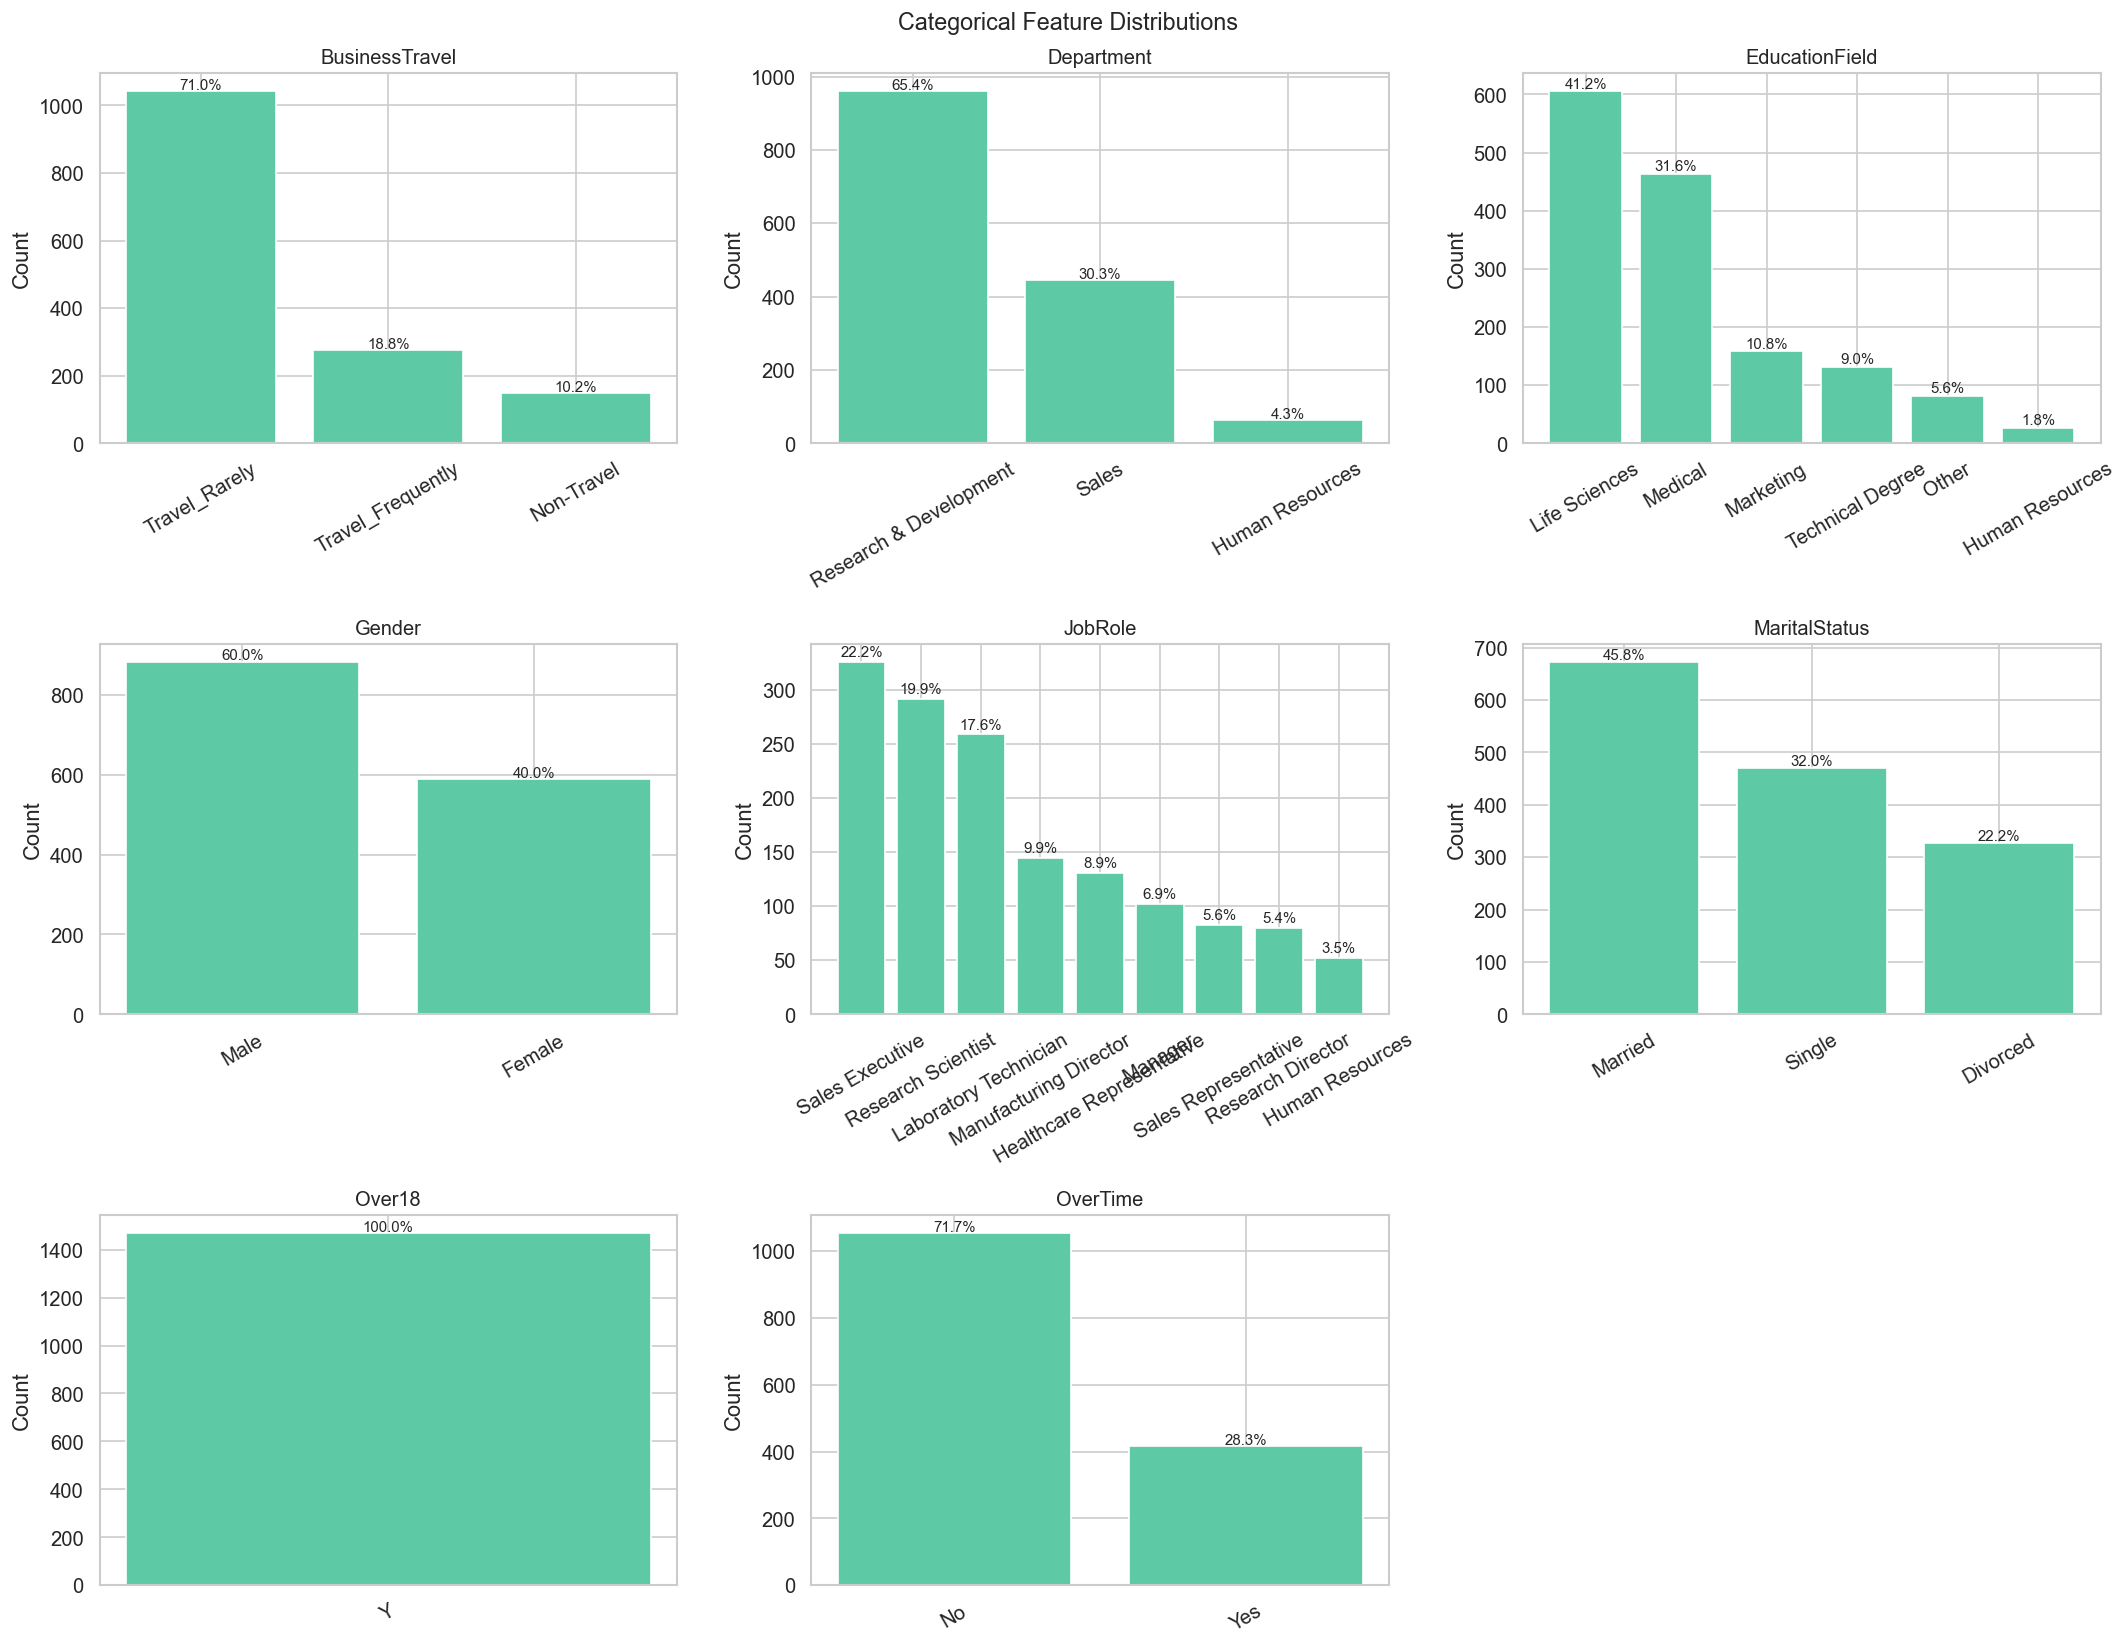

In [33]:
# Categorical variable distributions 
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ax = axes[i]
    order = df[col].value_counts().index
    counts = df[col].value_counts()
    total = len(df)
    
    bars = ax.bar(order, counts.values,
                  color='#5DCAA5', edgecolor='white')
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    
    # Add percentage labels on bars
    for bar, count in zip(bars, counts.values):
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 5,
                f'{pct:.1f}%',
                ha='center', fontsize=9)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('categorical_distributions.png', bbox_inches='tight')
plt.show()

In [34]:
# Categorical representation check 
print("Categorical column analysis:\n")

for col in cat_features:
    counts = df[col].value_counts()
    pcts = df[col].value_counts(normalize=True) * 100
    dominant_pct = pcts.iloc[0]
    
    print(f"{col}:")
    for cat, pct in pcts.items():
        if pct < 1:
            flag = " ← very rare, consider dropping"
        elif pct < 5:
            flag = " ← rare, consider grouping"
        elif pct < 10:
            flag = " ← acceptable, monitor"
        else:
            flag = ""
        print(f"  {str(cat):30s} {pct:.1f}%{flag}")
    
    if dominant_pct > 85:
        print(f"  ⚠ Dominant category at {dominant_pct:.1f}% — low predictive value")
    elif dominant_pct > 70:
        print(f"  ⚠ Concentrated — top category at {dominant_pct:.1f}%")
    print()

Categorical column analysis:

BusinessTravel:
  Travel_Rarely                  71.0%
  Travel_Frequently              18.8%
  Non-Travel                     10.2%
  ⚠ Concentrated — top category at 71.0%

Department:
  Research & Development         65.4%
  Sales                          30.3%
  Human Resources                4.3% ← rare, consider grouping

EducationField:
  Life Sciences                  41.2%
  Medical                        31.6%
  Marketing                      10.8%
  Technical Degree               9.0% ← acceptable, monitor
  Other                          5.6% ← acceptable, monitor
  Human Resources                1.8% ← rare, consider grouping

Gender:
  Male                           60.0%
  Female                         40.0%

JobRole:
  Sales Executive                22.2%
  Research Scientist             19.9%
  Laboratory Technician          17.6%
  Manufacturing Director         9.9% ← acceptable, monitor
  Healthcare Representative      8.9% ← acceptabl

### Finding
Seven categorical columns were analysed across 1,470 employee records. 
All categories are represented with meaningful counts and distributions 
align with what would be expected in a real organisation.

**BusinessTravel** — 71% of employees travel rarely which is typical. 
Frequent travel is a minority requirement concentrated likely in 
sales and client facing roles.

**Department** — Research and Development dominates at 65.4% followed 
by Sales at 30.3%. Human Resources at 4.3% is flagged as rare but 
reflects the reality that HR departments are typically small relative 
to the rest of the organisation. No grouping required.

**EducationField** — Life Sciences and Medical together account for 
72.8% which is consistent with an IBM technology and healthcare 
focused workforce. Human Resources at 1.8% is rare but meaningful 
enough to retain.

**Gender** — 60% Male and 40% Female. Reasonable representation 
across both categories with no dominance concern.

**JobRole** — Nine distinct roles with Sales Executive, Research 
Scientist and Laboratory Technician being the three largest segments. 
Human Resources at 3.5% is the only role approaching rare threshold 
but retains enough records to be meaningful.

**MaritalStatus** — Well distributed across all three categories 
with no dominance concern.

**OverTime** — 71.7% of employees do not work overtime which is 
expected. Companies generally do not want overtime to be the norm 
as it signals resourcing problems.

**Over18** — Confirmed constant column with 100% of employees 
marked Y. This adds no analytical value and will be dropped 
during preprocessing as previously flagged.

### Implication
No categorical column requires grouping or dropping based on 
representation alone. All distributions reflect realistic 
organisational structures and no data collection anomalies 
were detected.

### Action
All categorical columns except Over18 will be retained for 
analysis and encoding during preprocessing. Over18 remains 
on the drop list confirmed from our earlier quality checks.

### Outlier Detection

**Purpose:** Identify extreme values in numerical columns that sit 
far outside the normal range of the data.

**Why it matters:** Outliers can distort statistical measures like 
the mean and standard deviation, skew our visualisations and in 
some models pull the decision boundary in the wrong direction.

**What we are looking for:**
- Values that fall significantly below Q1 or above Q3
- Whether outliers are genuine extreme cases or data errors
- How many outliers exist as a percentage of the dataset

**Method:** We will use the IQR method which defines outliers as 
any value below Q1 minus 1.5 times the IQR or above Q3 plus 
1.5 times the IQR.

In [37]:
# IQR outlier detection
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_fence) | (df[col] > upper_fence)]
    return Q1, Q3, IQR, lower_fence, upper_fence, len(outliers)

print(f"{'Column':35s} {'Q1':>8} {'Q3':>8} {'IQR':>8} "
      f"{'Lower':>8} {'Upper':>8} {'Outliers':>10} {'%':>6}")
print("─" * 95)

for col in num_cols:
    Q1, Q3, IQR, lower, upper, n_outliers = detect_outliers_iqr(df, col)
    pct = n_outliers / len(df) * 100
    flag = " ←" if n_outliers > 0 else ""
    print(f"{col:35s} {Q1:>8.1f} {Q3:>8.1f} {IQR:>8.1f} "
          f"{lower:>8.1f} {upper:>8.1f} {n_outliers:>10} {pct:>5.1f}%{flag}")

Column                                    Q1       Q3      IQR    Lower    Upper   Outliers      %
───────────────────────────────────────────────────────────────────────────────────────────────
Age                                     30.0     43.0     13.0     10.5     62.5          0   0.0%
DailyRate                              465.0   1157.0    692.0   -573.0   2195.0          0   0.0%
DistanceFromHome                         2.0     14.0     12.0    -16.0     32.0          0   0.0%
Education                                2.0      4.0      2.0     -1.0      7.0          0   0.0%
EnvironmentSatisfaction                  2.0      4.0      2.0     -1.0      7.0          0   0.0%
HourlyRate                              48.0     83.8     35.8     -5.6    137.4          0   0.0%
JobInvolvement                           2.0      3.0      1.0      0.5      4.5          0   0.0%
JobLevel                                 1.0      3.0      2.0     -2.0      6.0          0   0.0%
JobSatisfacti

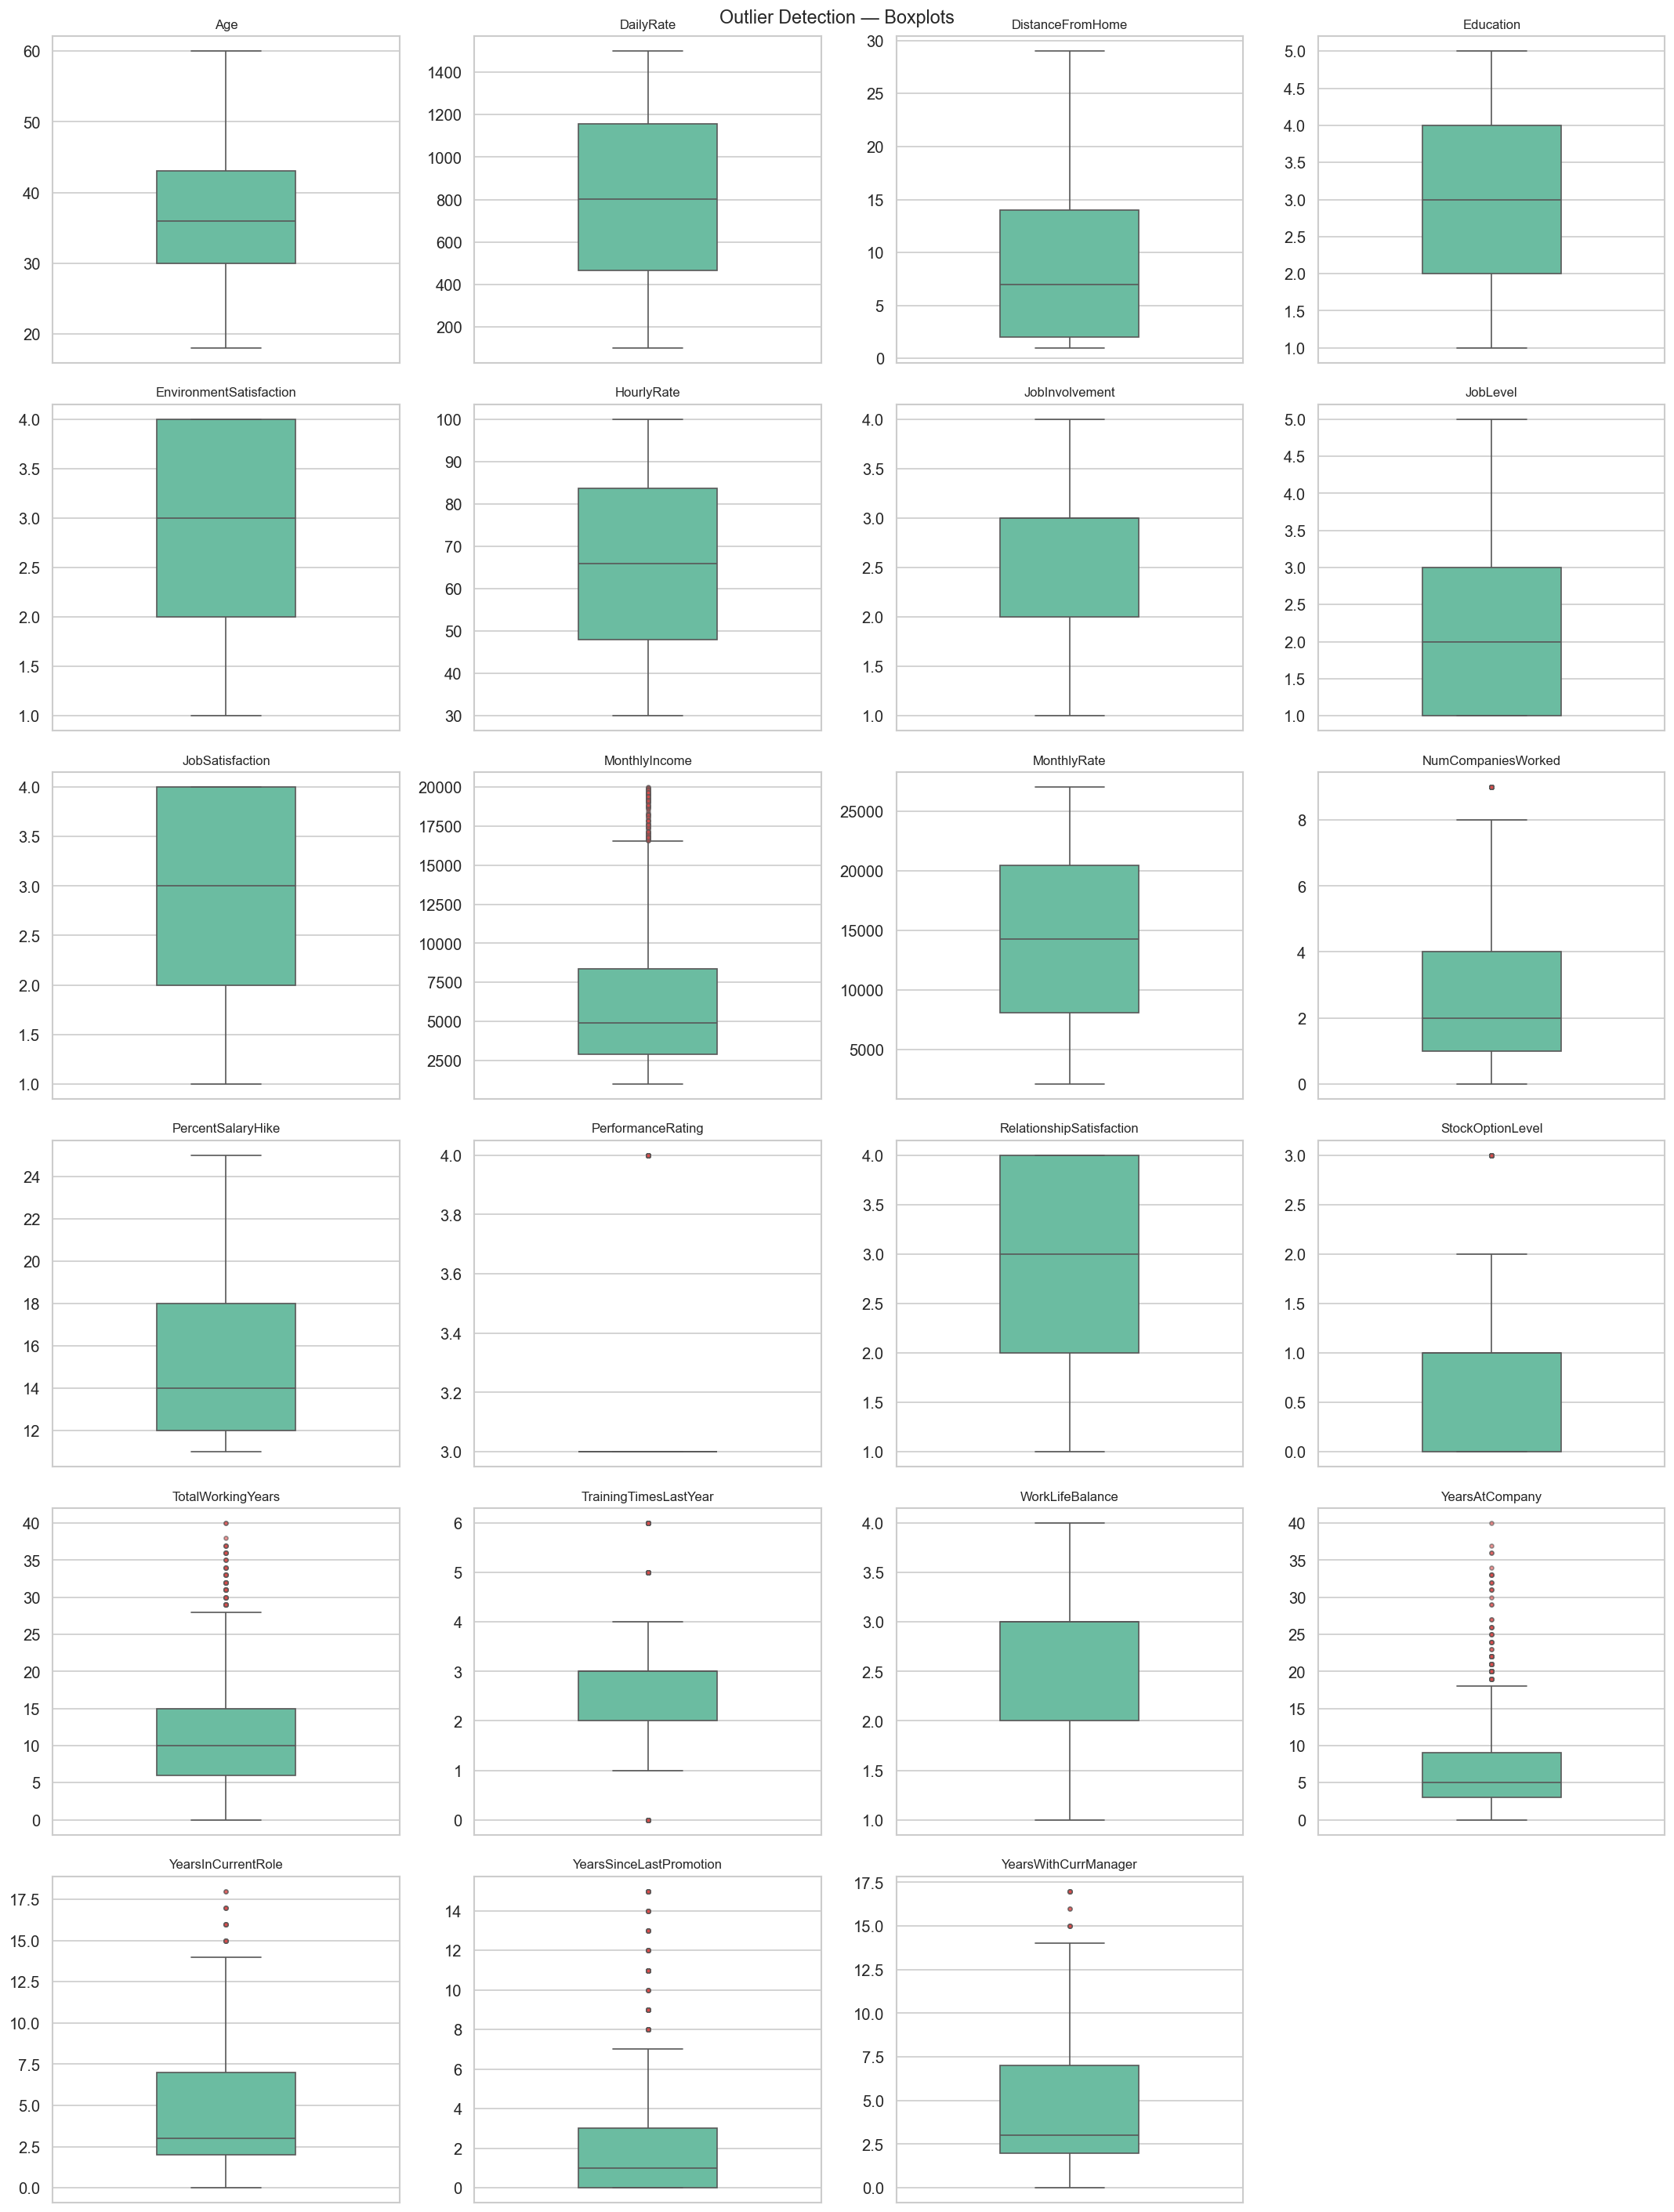

In [38]:
# ── Boxplots for all numerical columns ────────────────────────────────
n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.boxplot(y=df[col], ax=ax, color='#5DCAA5', width=0.4,
                flierprops=dict(marker='o', 
                               markerfacecolor='#E24B4A',
                               markersize=3, 
                               alpha=0.6))
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection — Boxplots', fontsize=14)
plt.tight_layout()
plt.savefig('outlier_boxplots.png', bbox_inches='tight')
plt.show()

### Finding
Outlier detection using the IQR method identified outliers across 
several numerical columns. The most notable columns with outliers are 
MonthlyIncome, TotalWorkingYears, YearsAtCompany, YearsSinceLastPromotion, 
NumCompaniesWorked and DistanceFromHome.

### Implication
All identified outliers represent genuine extreme cases that reflect 
realistic employee profiles — high earners, long serving employees, 
frequent job changers and long distance commuters. These are not 
data errors and removing them would mean discarding real and 
potentially informative employee profiles.

PerformanceRating outliers are an artifact of the column's low 
variance problem identified earlier rather than genuine extreme 
values. With only two active rating levels the IQR method produces 
misleading outlier flags for this column.

### Action
No outliers will be removed. Logistic regression is sufficiently 
robust to handle the magnitude of outliers present in this dataset. 
StandardScaler will be applied during preprocessing which will 
reduce the influence of extreme values by normalising all features 
to the same scale.

### Feature vs Target Analysis

**Purpose:** Understand how each feature relates to our target 
variable — Attrition.

**Why it matters:** This is the core of our EDA. We are identifying 
which features most strongly differentiate employees who left from 
employees who stayed. These findings will directly inform our model 
and our recommendations to the business.

**What we are looking for:**
- Categorical features where one category has a dramatically 
  higher attrition rate than others
- Numerical features where leavers show a systematically 
  different profile from stayers
- Any surprising or counterintuitive patterns worth investigating

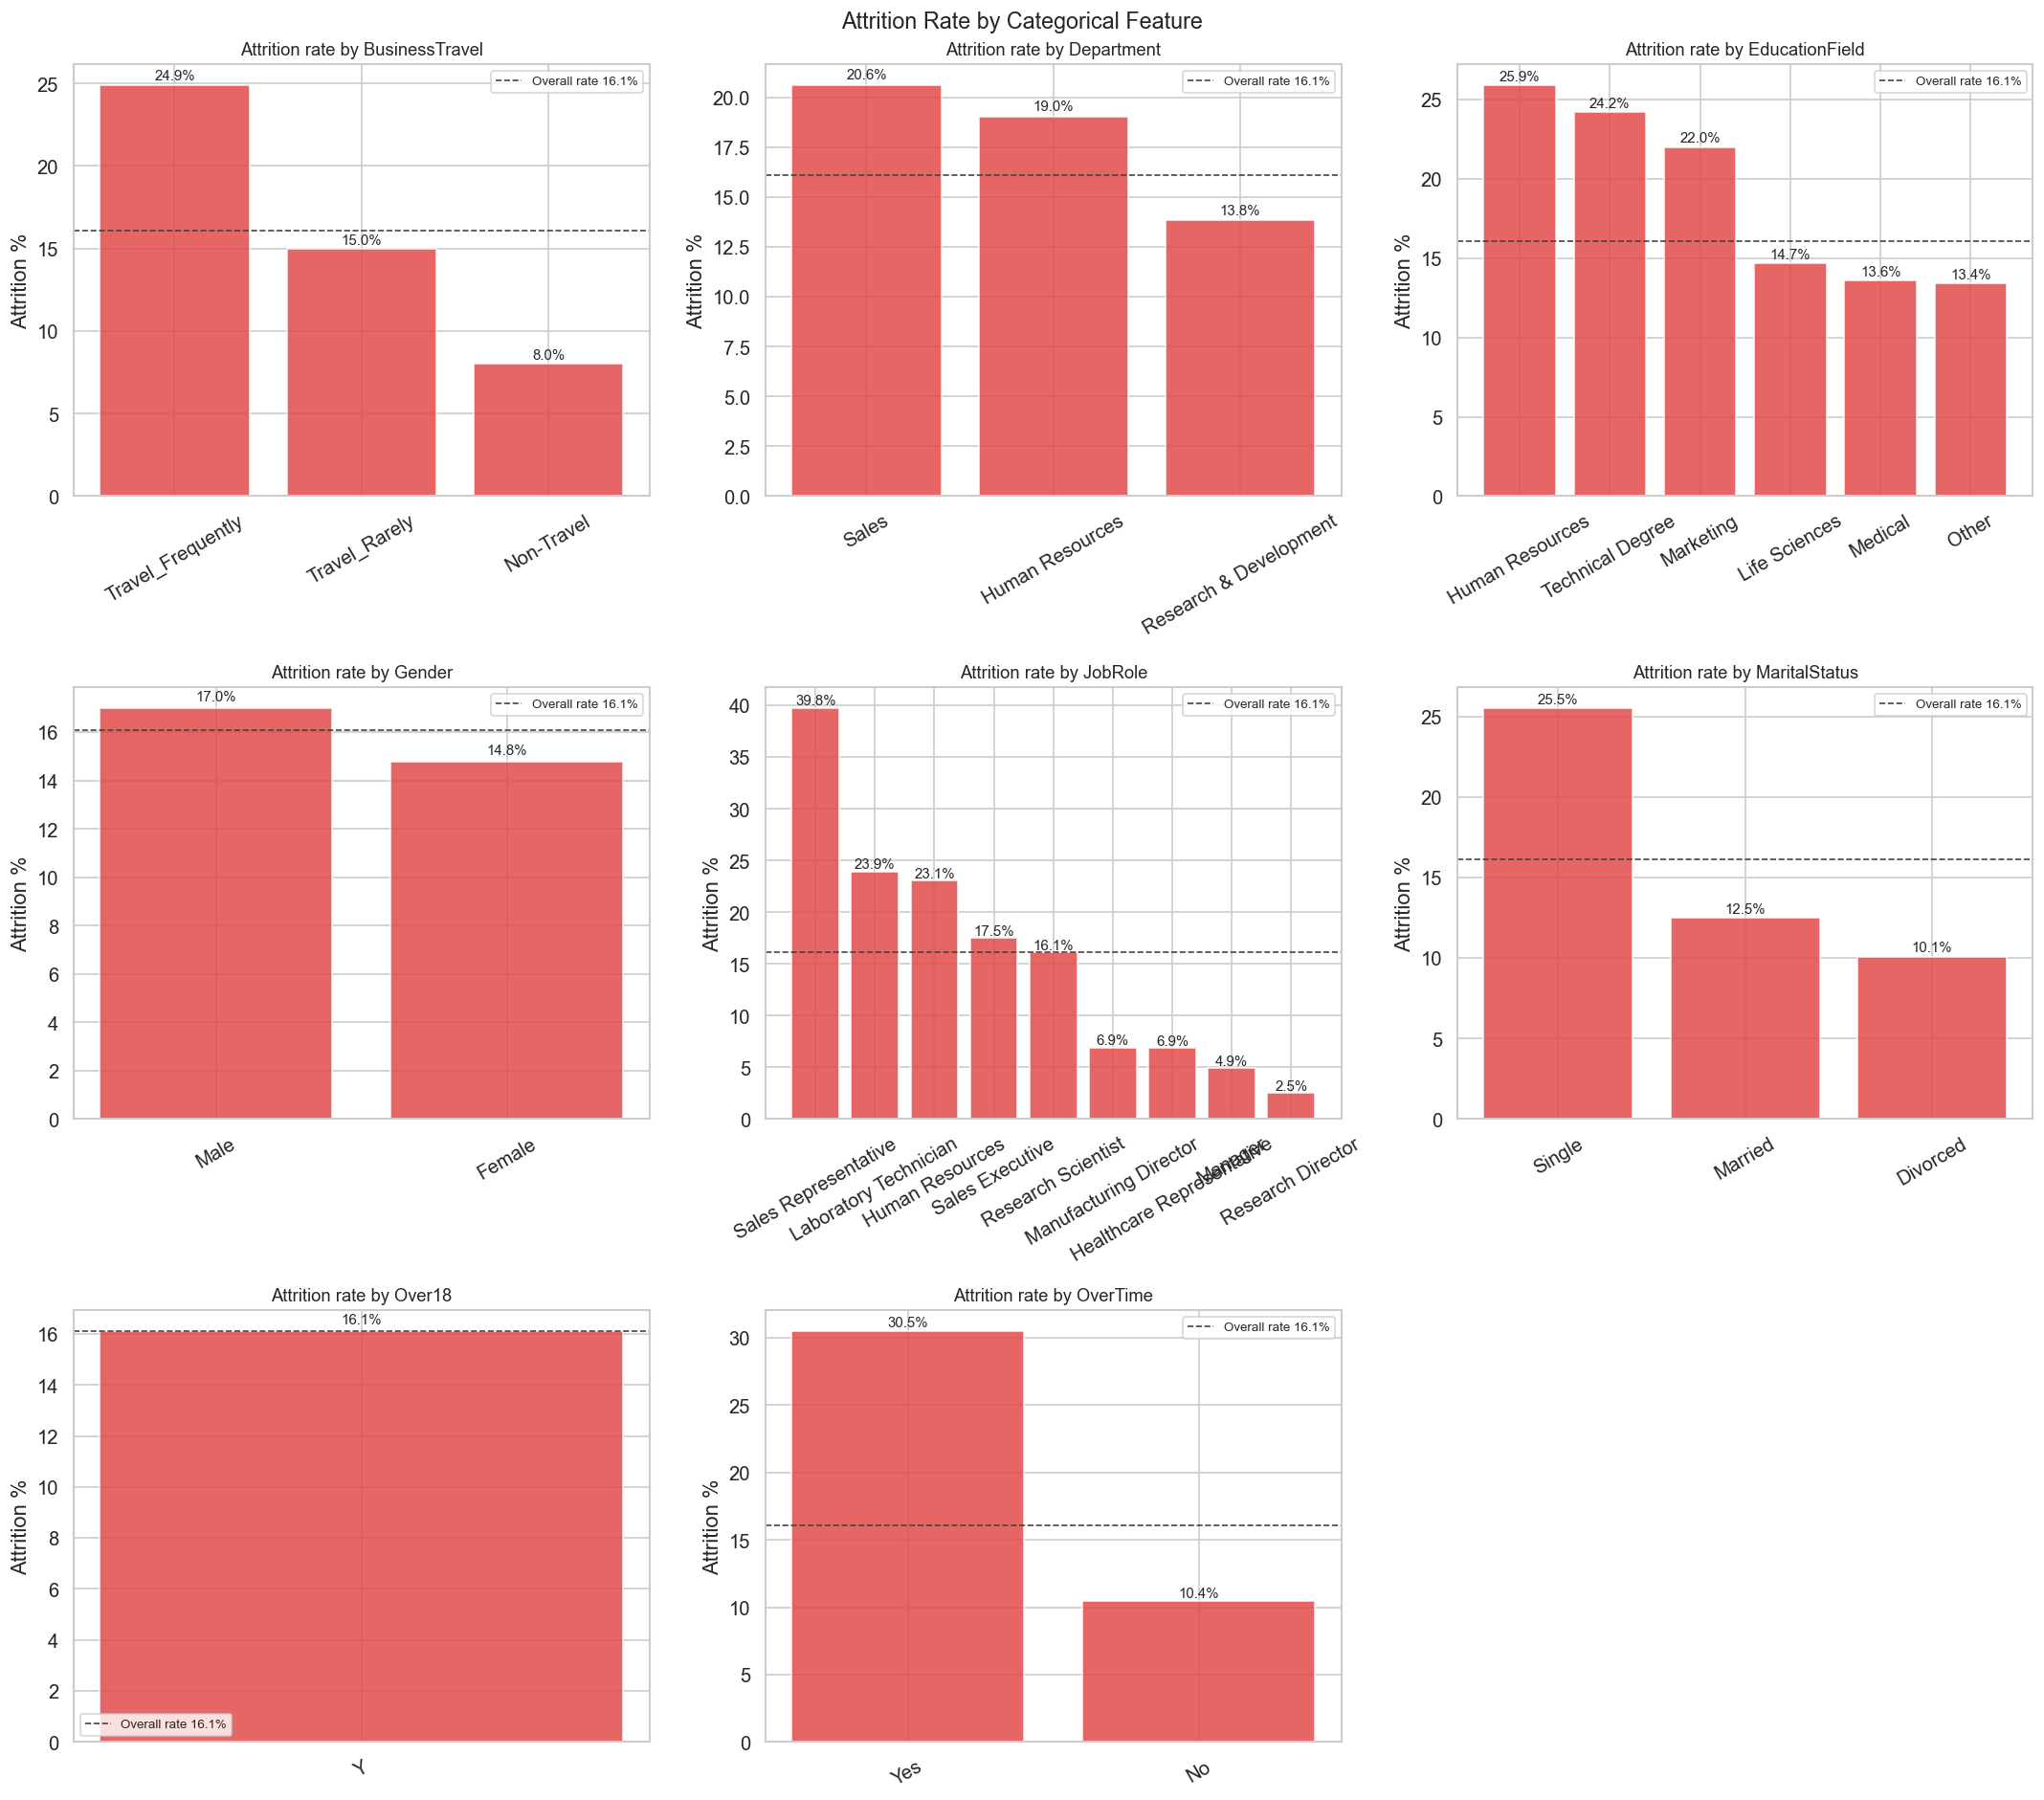

In [41]:
# Attrition rate by categorical feature 
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ax = axes[i]
    
    # Calculate attrition rate per category
    attrition_rate = (
        df.groupby(col)['Attrition']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .reset_index()
        .sort_values('Attrition', ascending=False)
    )
    
    bars = ax.bar(attrition_rate[col], 
                  attrition_rate['Attrition'],
                  color='#E24B4A', 
                  edgecolor='white',
                  alpha=0.85)
    
    # Overall attrition rate reference line
    ax.axhline(y=16.1, color='#444441', 
               linestyle='--', linewidth=1,
               label='Overall rate 16.1%')
    
    ax.set_title(f'Attrition rate by {col}', fontsize=11)
    ax.set_ylabel('Attrition %')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    
    # Add percentage labels
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f"{bar.get_height():.1f}%",
                ha='center', fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Attrition Rate by Categorical Feature', fontsize=14)
plt.tight_layout()
plt.savefig('attrition_by_category.png', bbox_inches='tight')
plt.show()

In [42]:
# Exact attrition rates by all categorical features
for col in cat_features:
    print(f"\n{col}:")
    attrition_rate = (
        df.groupby(col)['Attrition']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .reset_index()
        .sort_values('Attrition', ascending=False)
    )
    attrition_rate.columns = [col, 'Attrition Rate %']
    attrition_rate['Attrition Rate %'] = attrition_rate['Attrition Rate %'].round(1)
    attrition_rate['vs Overall'] = (attrition_rate['Attrition Rate %'] - 16.1).round(1)
    attrition_rate['vs Overall'] = attrition_rate['vs Overall'].apply(
        lambda x: f"+{x}%" if x > 0 else f"{x}%"
    )
    print(attrition_rate.to_string(index=False))
    print(f"{'─' * 45}")


BusinessTravel:
   BusinessTravel  Attrition Rate % vs Overall
Travel_Frequently              24.9      +8.8%
    Travel_Rarely              15.0      -1.1%
       Non-Travel               8.0      -8.1%
─────────────────────────────────────────────

Department:
            Department  Attrition Rate % vs Overall
                 Sales              20.6      +4.5%
       Human Resources              19.0      +2.9%
Research & Development              13.8      -2.3%
─────────────────────────────────────────────

EducationField:
  EducationField  Attrition Rate % vs Overall
 Human Resources              25.9      +9.8%
Technical Degree              24.2      +8.1%
       Marketing              22.0      +5.9%
   Life Sciences              14.7      -1.4%
         Medical              13.6      -2.5%
           Other              13.4      -2.7%
─────────────────────────────────────────────

Gender:
Gender  Attrition Rate % vs Overall
  Male              17.0      +0.9%
Female          

### Finding
Categorical feature analysis reveals several strong attrition signals:

**Strongest signals — above overall rate of 16.1%:**
- OverTime Yes: 30.5% — nearly 3x higher than non-overtime employees (10.4%)
- Sales Representative: 39.8% — highest attrition of any single category
- Single employees: 25.5% — 9.4 percentage points above overall rate
- Frequent travellers: 24.9% — 8.8 percentage points above overall rate
- Human Resources: elevated attrition consistently across Department, 
  EducationField and JobRole dimensions

**Protective factors — below overall rate of 16.1%:**
- Research Director: 2.5% and Manager: 4.9% — senior roles show 
  dramatically lower attrition
- Non-Travel employees: 8.0% — stability appears protective
- Married and Divorced employees show below average attrition rates

**Minimal signal:**
- Gender shows only a 2.2 percentage point difference between 
  Male (17.0%) and Female (14.8%)

### Implication
A clear high risk employee profile emerges — junior employees in 
Sales or HR roles, working overtime, travelling frequently and 
without family commitments show the highest concentration of 
attrition risk. Seniority and stability are the strongest 
protective factors.

The use of MaritalStatus and Gender as predictive features raises 
ethical considerations around using personal demographic information 
in HR decision making. This will be documented as a model limitation.

### Action
OverTime, JobRole, MaritalStatus and BusinessTravel will be monitored 
closely as expected strong predictors in the logistic regression model. 
Gender will be retained for now but is expected to produce a near 
zero coefficient and may be dropped in model refinement.

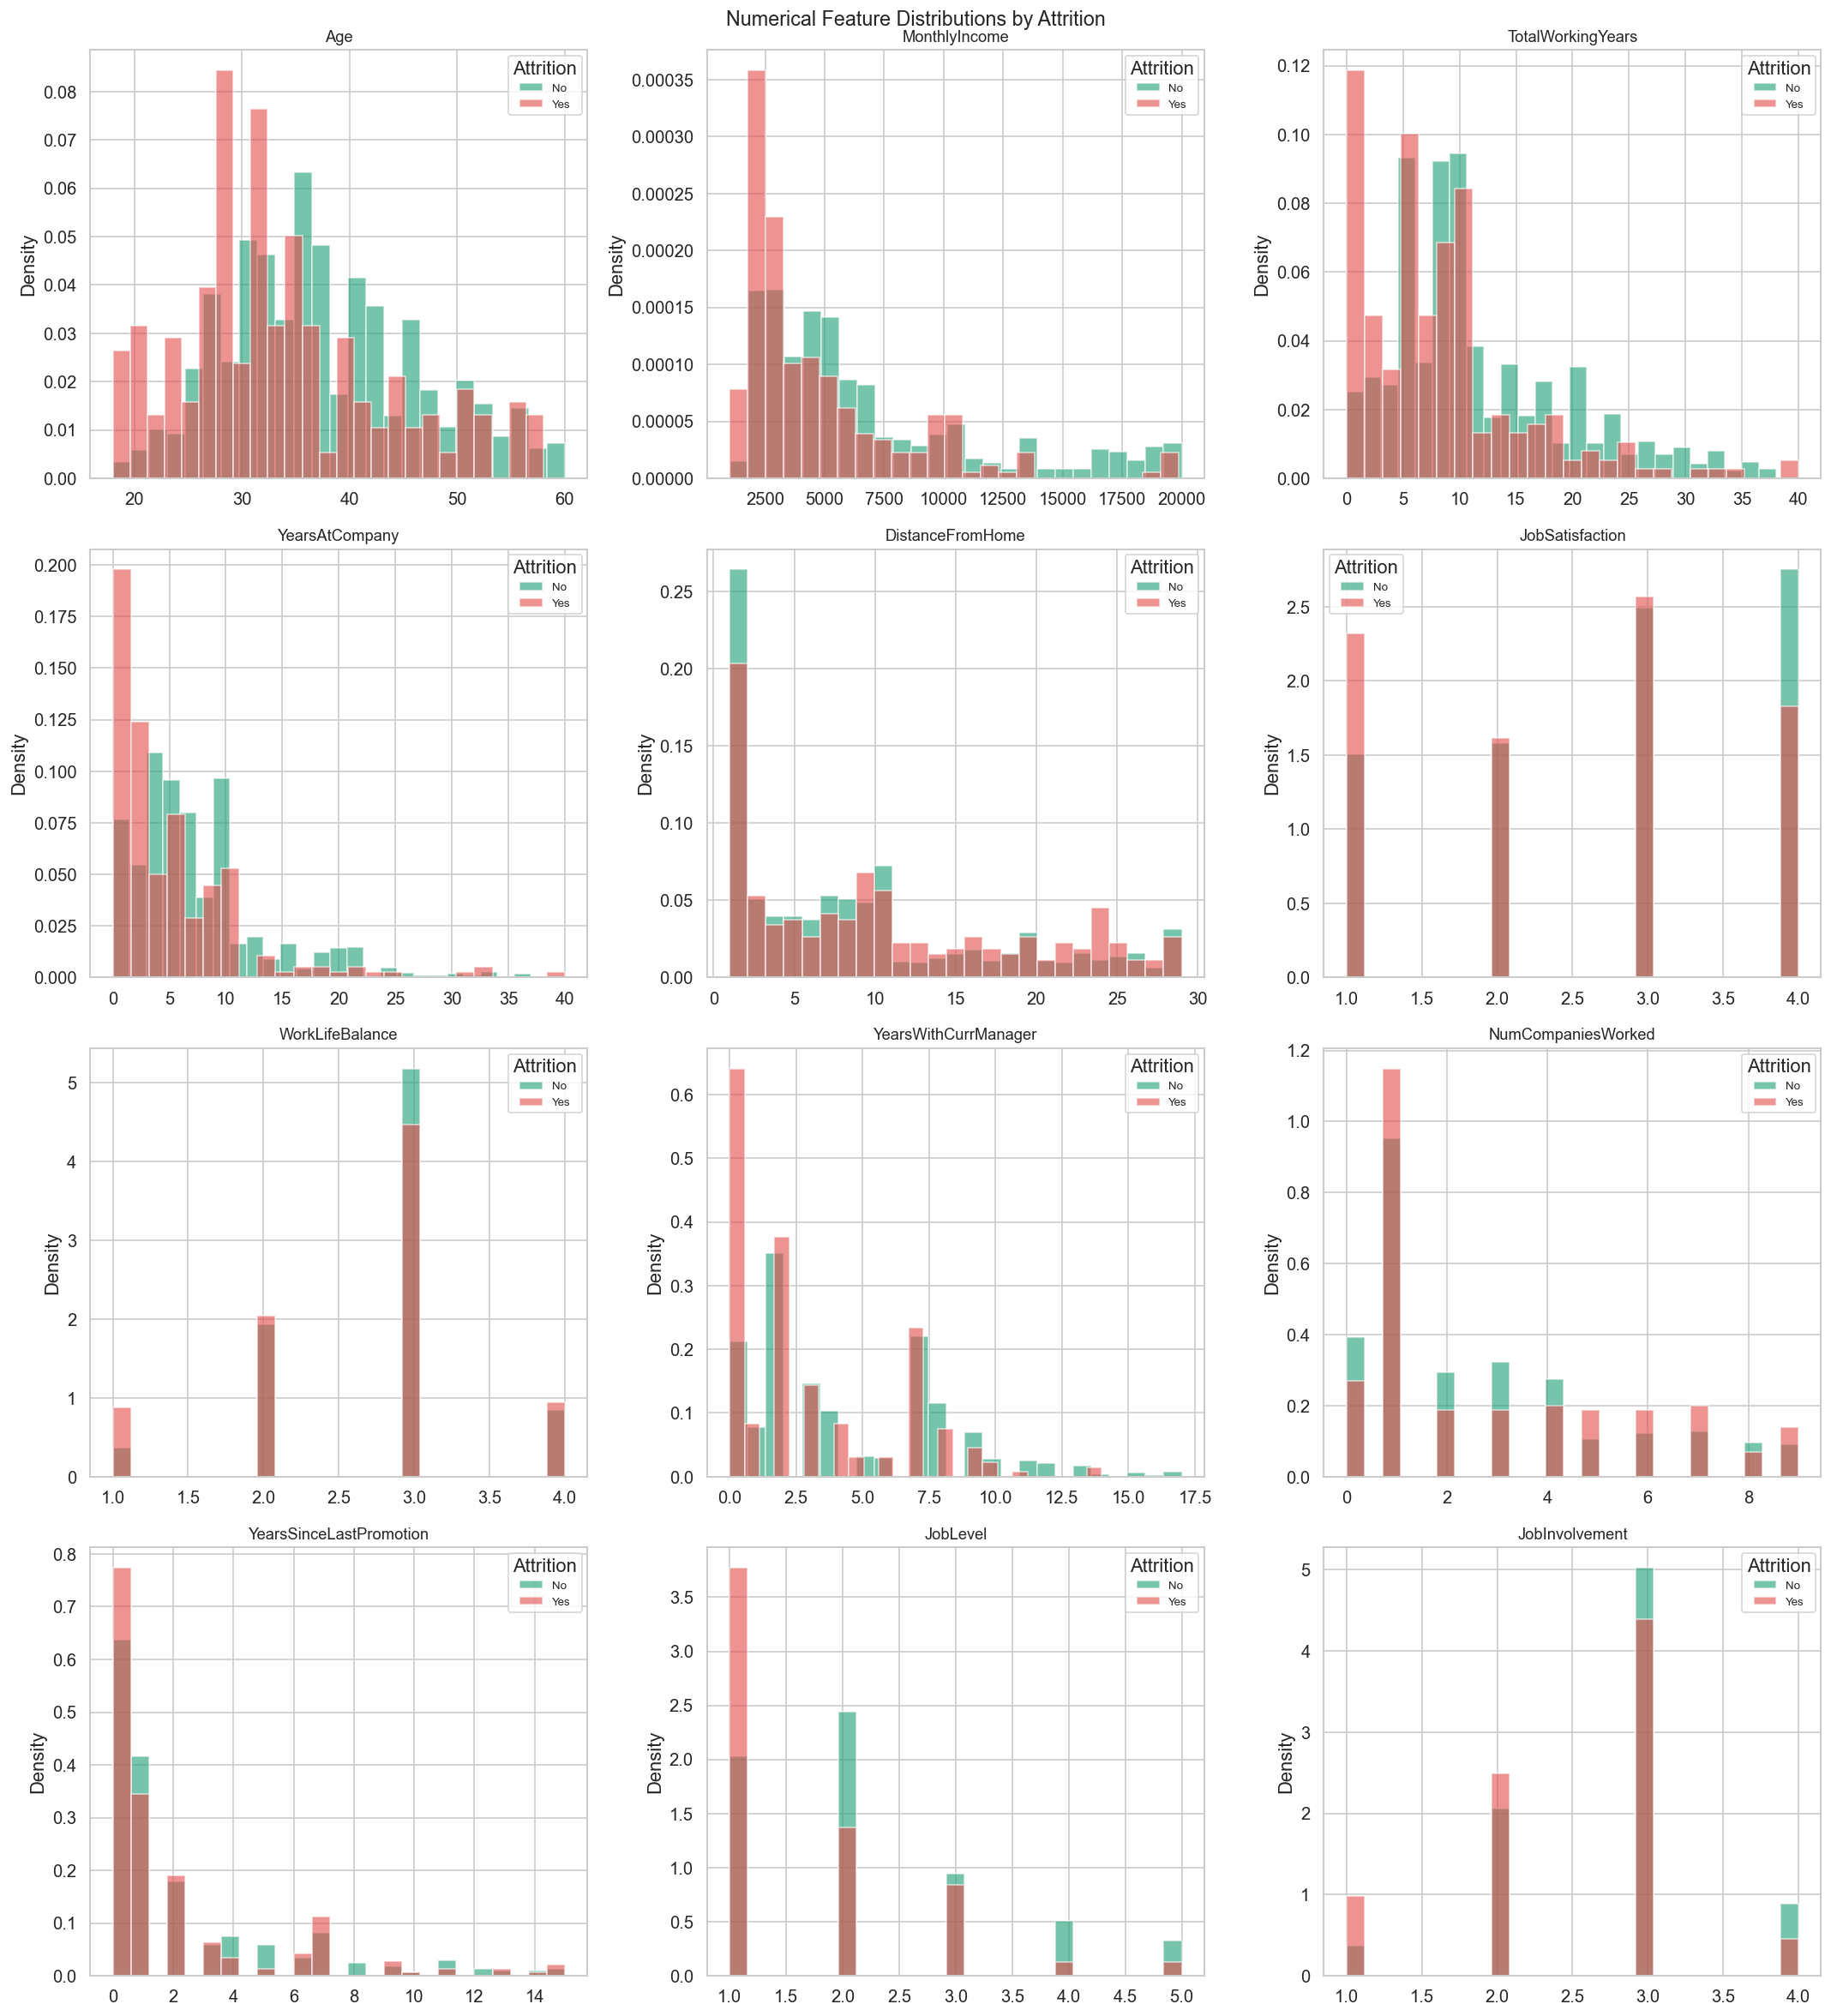

In [44]:
# ── Numerical features vs Attrition ──────────────────────────────────
key_num_features = [
    'Age', 'MonthlyIncome', 'TotalWorkingYears',
    'YearsAtCompany', 'DistanceFromHome', 'JobSatisfaction',
    'WorkLifeBalance', 'YearsWithCurrManager', 
    'NumCompaniesWorked', 'YearsSinceLastPromotion',
    'JobLevel', 'JobInvolvement'
]

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(key_num_features):
    ax = axes[i]
    
    for label, color in [('No', '#1D9E75'), ('Yes', '#E24B4A')]:
        subset = df[df['Attrition'] == label][col]
        ax.hist(subset, bins=25, alpha=0.6, 
                color=color, label=label, density=True)
    
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Density')
    ax.legend(title='Attrition', fontsize=8)

plt.suptitle('Numerical Feature Distributions by Attrition', 
             fontsize=14)
plt.tight_layout()
plt.savefig('numerical_vs_attrition.png', bbox_inches='tight')
plt.show()

In [45]:
# Median comparison — leavers vs stayers
comparison = (
    df.groupby('Attrition')[key_num_features]
    .median()
    .T
    .round(1)
)

comparison.columns = ['Stayed', 'Left']
comparison['Difference'] = (comparison['Left'] - comparison['Stayed']).round(1)
comparison['Difference %'] = (
    (comparison['Left'] - comparison['Stayed']) 
    / comparison['Stayed'] * 100
).round(1)

comparison = comparison.sort_values('Difference %')

print("Median values — Stayed vs Left:\n")
print(comparison.to_string())

Median values — Stayed vs Left:

                         Stayed    Left  Difference  Difference %
YearsAtCompany              6.0     3.0        -3.0         -50.0
NumCompaniesWorked          2.0     1.0        -1.0         -50.0
JobLevel                    2.0     1.0        -1.0         -50.0
MonthlyIncome            5204.0  3202.0     -2002.0         -38.5
YearsWithCurrManager        3.0     2.0        -1.0         -33.3
TotalWorkingYears          10.0     7.0        -3.0         -30.0
Age                        36.0    32.0        -4.0         -11.1
JobSatisfaction             3.0     3.0         0.0           0.0
WorkLifeBalance             3.0     3.0         0.0           0.0
YearsSinceLastPromotion     1.0     1.0         0.0           0.0
JobInvolvement              3.0     3.0         0.0           0.0
DistanceFromHome            7.0     9.0         2.0          28.6


In [46]:
# Deeper look at zero difference columns
zero_diff_cols = [
    'JobSatisfaction', 'WorkLifeBalance', 
    'YearsSinceLastPromotion', 'JobInvolvement'
]

for col in zero_diff_cols:
    print(f"\n{col} — full distribution by Attrition:")
    cross = pd.crosstab(
        df[col], 
        df['Attrition'], 
        normalize='columns'
    ) * 100
    cross = cross.round(1)
    cross.columns = ['Stayed %', 'Left %']
    cross['Difference'] = (cross['Left %'] - cross['Stayed %']).round(1)
    print(cross.to_string())
    print("─" * 40)


JobSatisfaction — full distribution by Attrition:
                 Stayed %  Left %  Difference
JobSatisfaction                              
1                    18.1    27.8         9.7
2                    19.0    19.4         0.4
3                    29.9    30.8         0.9
4                    33.0    21.9       -11.1
────────────────────────────────────────

WorkLifeBalance — full distribution by Attrition:
                 Stayed %  Left %  Difference
WorkLifeBalance                              
1                     4.5    10.5         6.0
2                    23.2    24.5         1.3
3                    62.1    53.6        -8.5
4                    10.2    11.4         1.2
────────────────────────────────────────

YearsSinceLastPromotion — full distribution by Attrition:
                         Stayed %  Left %  Difference
YearsSinceLastPromotion                              
0                            38.2    46.4         8.2
1                            25.0    20.7  

### Finding
Numerical feature analysis reveals two distinct types of signals:

**Strong median differences — continuous variables:**
- MonthlyIncome: leavers earn 38.5% less than stayers 
  (median $3,202 vs $5,204)
- YearsAtCompany: leavers have 50% shorter tenure 
  (median 3 years vs 6 years)
- JobLevel: leavers are 50% more junior 
  (median level 1 vs level 2)
- YearsWithCurrManager: leavers have spent 33.3% less 
  time with their current manager
- TotalWorkingYears: leavers have 30% less overall 
  experience (median 7 years vs 10 years)
- Age: leavers are younger (median 32 vs 36)
- DistanceFromHome: leavers live 28.6% further from work

**Distributional differences — rating columns:**
Median comparison showed zero difference for JobSatisfaction, 
WorkLifeBalance, JobInvolvement and YearsSinceLastPromotion. 
However full distribution analysis revealed consistent patterns 
across all four — employees scoring at the lowest levels are 
disproportionately overrepresented among leavers while employees 
at the highest levels are disproportionately overrepresented 
among stayers.

### Implication
Low compensation, junior role level and short tenure are the 
strongest numerical predictors of attrition. The pattern suggests 
a critical window in the first three years of employment where 
attrition risk is highest — particularly for junior employees 
who feel underpaid relative to their expectations.

Rating columns require full distributional analysis rather than 
median comparison. Summarising them with a single central tendency 
measure masks the signal at the extremes which is precisely where 
the predictive power lies.

### Action
All numerical features showing meaningful differences will be 
retained for modeling. YearsSinceLastPromotion, JobSatisfaction, 
WorkLifeBalance and JobInvolvement will be included despite showing 
zero median difference — their distributional differences confirm 
they carry genuine predictive signal that the model will capture.

### Correlation Analysis

**Purpose:** Measure the statistical relationships between all 
numerical features and identify multicollinearity.

**Why it matters:** 
- Features that are highly correlated with each other carry 
  overlapping information — including both can confuse the model 
  and distort coefficients
- Understanding which features correlate with attrition helps 
  confirm and quantify the patterns we observed visually

**What we are looking for:**
- Which features correlate most strongly with attrition
- Any pairs of features with very high correlation between 
  themselves — multicollinearity
- Correlations above 0.75 between features will be flagged 
  as potential multicollinearity concerns

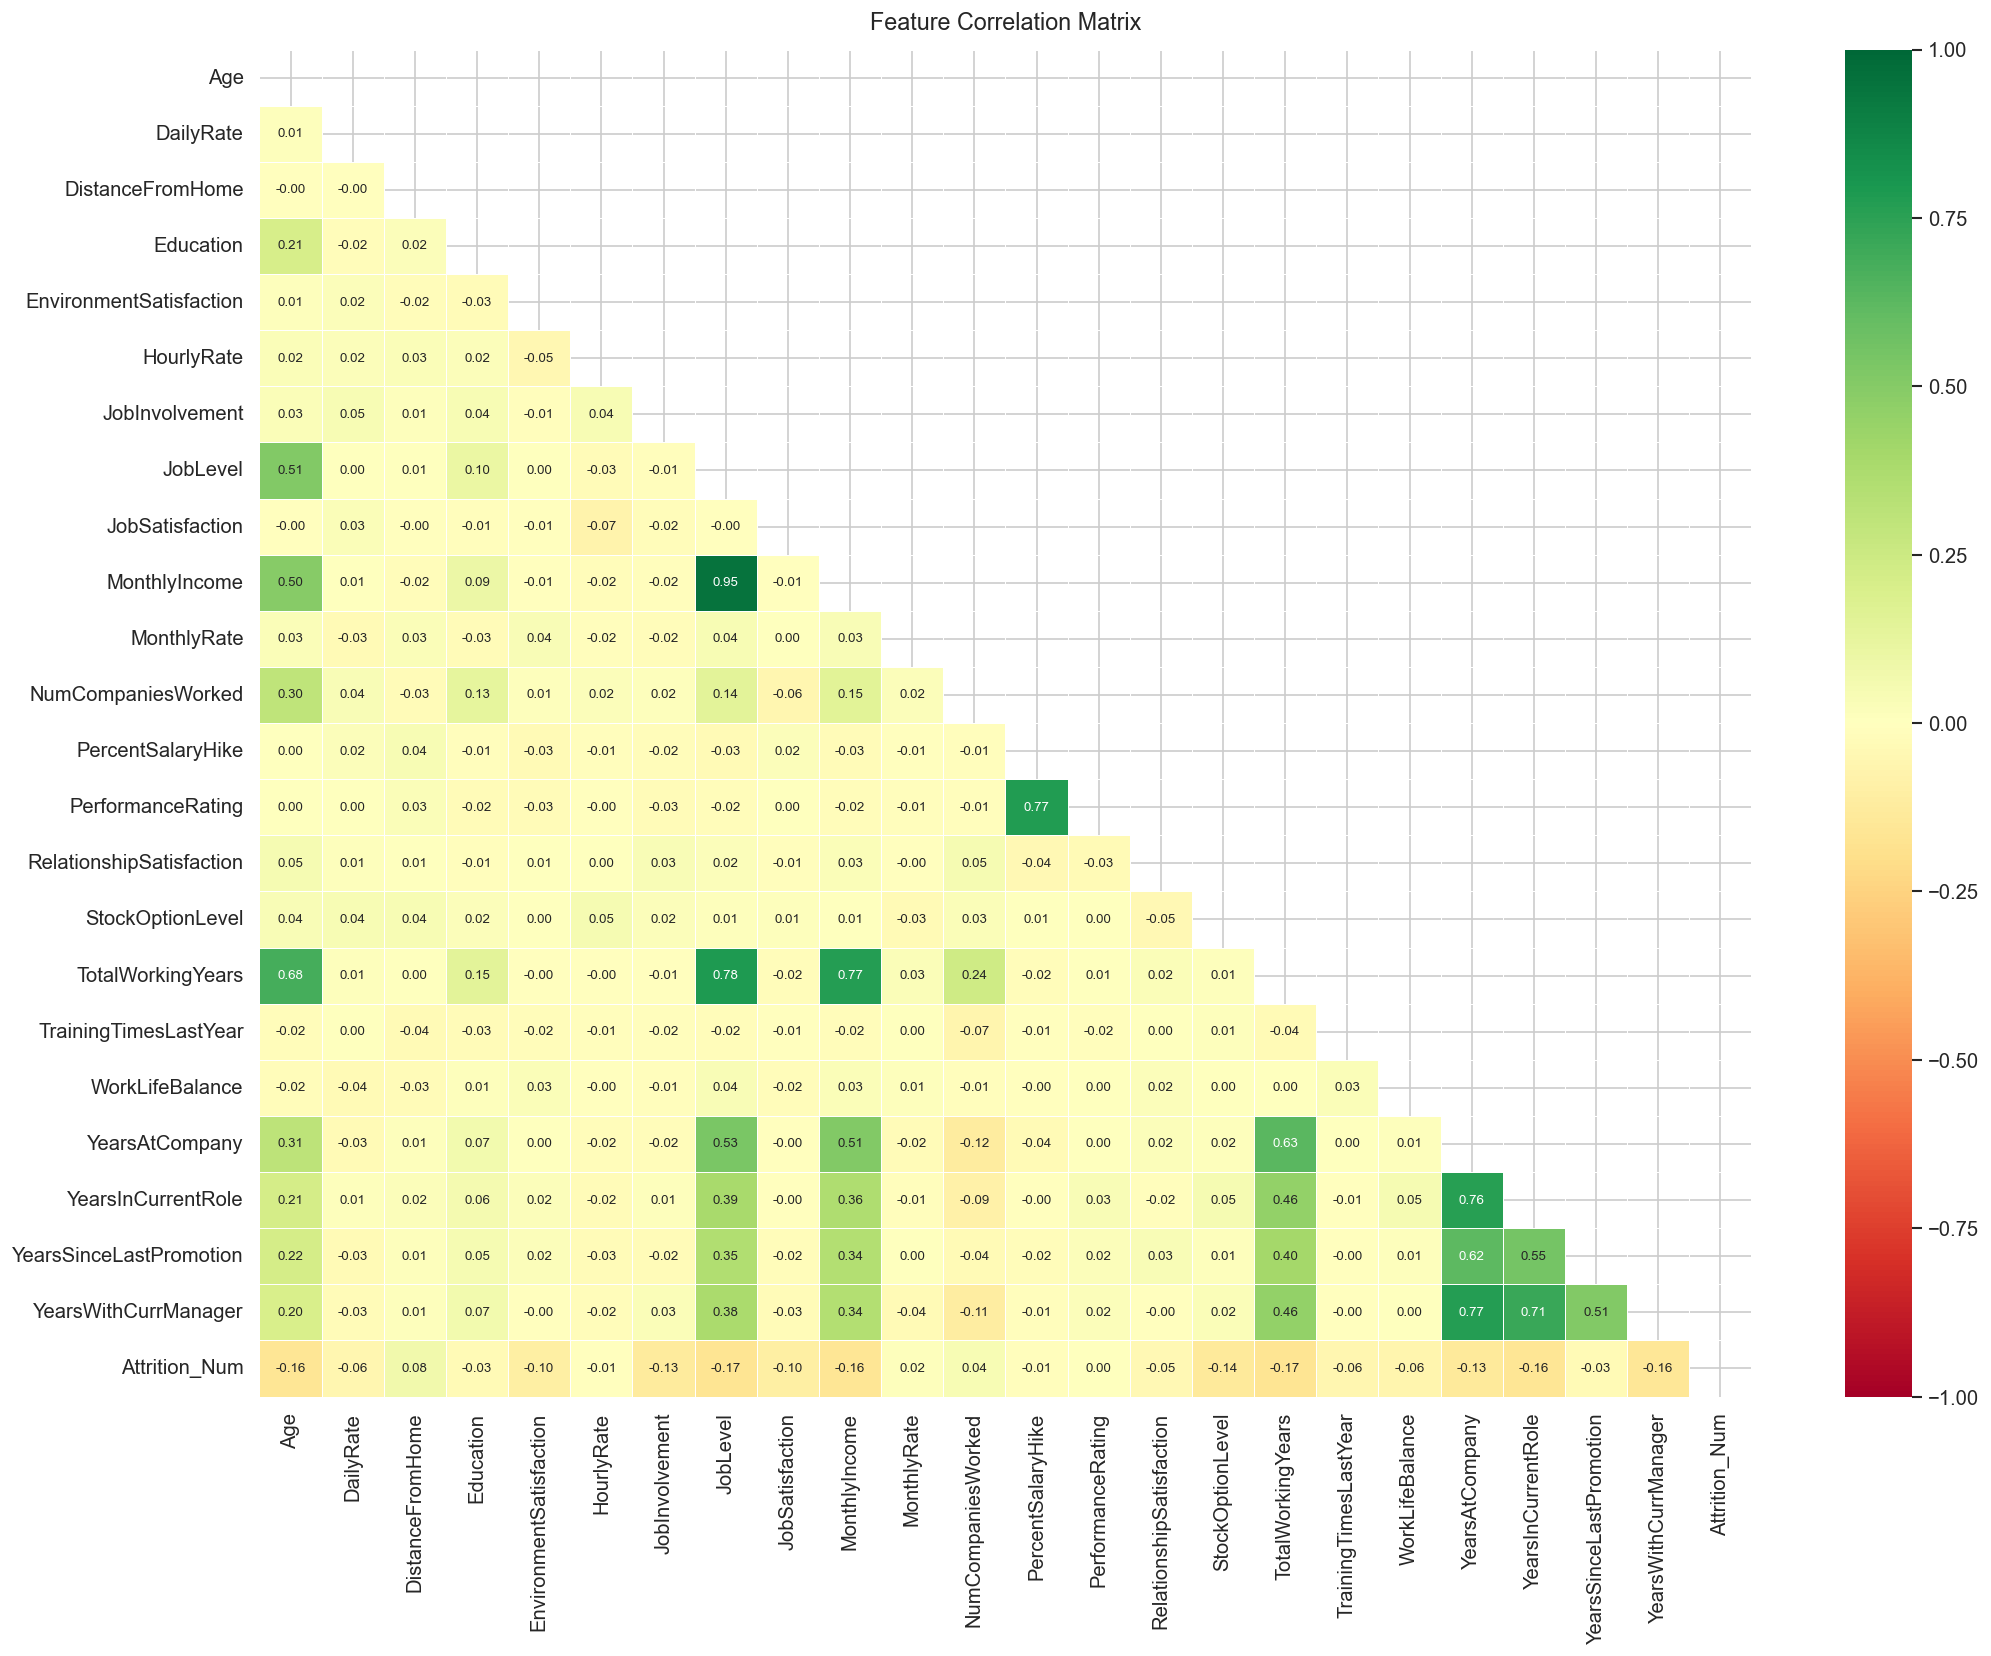

In [49]:
# Encode target for correlation
df['Attrition_Num'] = (df['Attrition'] == 'Yes').astype(int)

# Correlation matrix
corr_cols = num_cols + ['Attrition_Num']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 8},
    vmin=-1, vmax=1
)

ax.set_title('Feature Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [50]:
# Features most correlated with attrition
target_corr = (
    corr_matrix['Attrition_Num']
    .drop('Attrition_Num')
    .sort_values(key=abs, ascending=False)
)

print("Feature correlations with Attrition:\n")
for col, corr in target_corr.items():
    direction = "↑ higher = more attrition" if corr > 0 else "↓ lower = more attrition"
    print(f"  {col:35s} {corr:+.4f}   {direction}")

Feature correlations with Attrition:

  TotalWorkingYears                   -0.1711   ↓ lower = more attrition
  JobLevel                            -0.1691   ↓ lower = more attrition
  YearsInCurrentRole                  -0.1605   ↓ lower = more attrition
  MonthlyIncome                       -0.1598   ↓ lower = more attrition
  Age                                 -0.1592   ↓ lower = more attrition
  YearsWithCurrManager                -0.1562   ↓ lower = more attrition
  StockOptionLevel                    -0.1371   ↓ lower = more attrition
  YearsAtCompany                      -0.1344   ↓ lower = more attrition
  JobInvolvement                      -0.1300   ↓ lower = more attrition
  JobSatisfaction                     -0.1035   ↓ lower = more attrition
  EnvironmentSatisfaction             -0.1034   ↓ lower = more attrition
  DistanceFromHome                    +0.0779   ↑ higher = more attrition
  WorkLifeBalance                     -0.0639   ↓ lower = more attrition
  TrainingTi

In [51]:
# Multicollinearity check
print("Highly correlated feature pairs (|r| > 0.75):\n")

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.75:
            col_a = corr_matrix.columns[i]
            col_b = corr_matrix.columns[j]
            # Exclude attrition itself
            if col_a != 'Attrition_Num' and col_b != 'Attrition_Num':
                high_corr_pairs.append({
                    'Feature A': col_a,
                    'Feature B': col_b,
                    'Correlation': round(corr_val, 3)
                })

if high_corr_pairs:
    print(pd.DataFrame(high_corr_pairs).to_string(index=False))
else:
    print("No severe multicollinearity detected above 0.75 threshold")

Highly correlated feature pairs (|r| > 0.75):

           Feature A         Feature B  Correlation
       MonthlyIncome          JobLevel        0.950
   PerformanceRating PercentSalaryHike        0.774
   TotalWorkingYears          JobLevel        0.782
   TotalWorkingYears     MonthlyIncome        0.773
  YearsInCurrentRole    YearsAtCompany        0.759
YearsWithCurrManager    YearsAtCompany        0.769


### Finding
Correlation analysis confirms the patterns identified in the 
feature vs target analysis and reveals two important concerns.

**Features most correlated with attrition:**
The five strongest negative correlations are all seniority related —
TotalWorkingYears (-0.17), JobLevel (-0.17), YearsInCurrentRole (-0.16),
MonthlyIncome (-0.16) and Age (-0.16). Lower values in all five 
are associated with higher attrition risk.

Satisfaction and engagement columns show weaker but meaningful 
correlations ranging from -0.06 to -0.13. Their importance was 
better captured through distributional analysis than correlation 
coefficients alone.

Three features show negligible correlation with attrition —
HourlyRate (-0.007), PercentSalaryHike (-0.013) and 
PerformanceRating (+0.003). These are candidates for removal 
in model refinement.

**Multicollinearity — six flagged pairs:**

Seniority cluster:
- MonthlyIncome and JobLevel: 0.950 — severe multicollinearity
- TotalWorkingYears and JobLevel: 0.782
- TotalWorkingYears and MonthlyIncome: 0.773

Tenure cluster:
- YearsInCurrentRole and YearsAtCompany: 0.759
- YearsWithCurrManager and YearsAtCompany: 0.769

Performance cluster:
- PerformanceRating and PercentSalaryHike: 0.774

### Implication
Two distinct multicollinearity clusters exist in the data. 
The seniority cluster — MonthlyIncome, JobLevel, TotalWorkingYears 
and Age — are all measuring the same underlying concept from 
different angles. Similarly YearsAtCompany, YearsInCurrentRole 
and YearsWithCurrManager all measure tenure related dimensions.

The severe correlation between MonthlyIncome and JobLevel at 0.950 
is particularly concerning. Including both in the model will produce 
unstable and uninterpretable coefficients for these features.

Regularization via the C parameter in logistic regression will 
manage mild multicollinearity automatically. However the severe 
pair of MonthlyIncome and JobLevel requires a deliberate decision.

### Action
We will retain MonthlyIncome and drop JobLevel from the model 
since MonthlyIncome is more directly interpretable and meaningful 
to the business. For the tenure cluster we will retain YearsAtCompany 
as the primary tenure measure. 

HourlyRate, PercentSalaryHike and PerformanceRating will be flagged 
for removal in model refinement given their negligible correlation 
with attrition. All decisions will be validated through model 
coefficient analysis after training.

### Feature Engineering

**Purpose:** Create new features that better capture the underlying 
patterns in the data than the original columns alone.

**Why it matters:** Raw features do not always tell the complete 
story. Combining related features into composite scores can create 
stronger signals, reduce multicollinearity and produce more 
interpretable model outputs.

**Features we are creating:**
- EngagementScore — composite of all satisfaction and wellbeing ratings
- SeniorityScore — composite of career progression related features
- TenureScore — composite of company and role tenure related features

**Note:** We are creating these features alongside the originals 
at this stage for analysis purposes. Decisions on which version 
to use in the final model will be made during preprocessing.

In [54]:
# Feature engineering
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# EngagementScore
engagement_cols = [
    'JobSatisfaction', 
    'EnvironmentSatisfaction',
    'RelationshipSatisfaction', 
    'WorkLifeBalance'
]

# SeniorityScore
seniority_cols = [
    'Age', 
    'TotalWorkingYears', 
    'JobLevel', 
    'MonthlyIncome'
]

# TenureScore
tenure_cols = [
    'YearsAtCompany', 
    'YearsInCurrentRole', 
    'YearsWithCurrManager'
]

# Normalise and average each cluster
for score_name, cols in [
    ('EngagementScore', engagement_cols),
    ('SeniorityScore',  seniority_cols),
    ('TenureScore',     tenure_cols)
]:
    normalised = pd.DataFrame(
        scaler.fit_transform(df[cols]),
        columns=cols
    )
    df[score_name] = normalised.mean(axis=1).round(4)
    print(f"{score_name} created — range: "
          f"{df[score_name].min():.2f} to {df[score_name].max():.2f}")

EngagementScore created — range: 0.00 to 1.00
SeniorityScore created — range: 0.00 to 0.98
TenureScore created — range: 0.00 to 0.79


In [55]:
# Validate composite features against attrition
new_features = ['EngagementScore', 'SeniorityScore', 'TenureScore']

print("Composite feature correlations with Attrition:\n")
for feat in new_features:
    r = df[feat].corr(df['Attrition_Num'])
    print(f"  {feat:20s}: {r:+.4f}")

print("\nMedian values by Attrition:\n")
print(df.groupby('Attrition')[new_features].median().round(3).T)

Composite feature correlations with Attrition:

  EngagementScore     : -0.1591
  SeniorityScore      : -0.1865
  TenureScore         : -0.1666

Median values by Attrition:

Attrition           No    Yes
EngagementScore  0.583  0.500
SeniorityScore   0.291  0.183
TenureScore      0.175  0.101


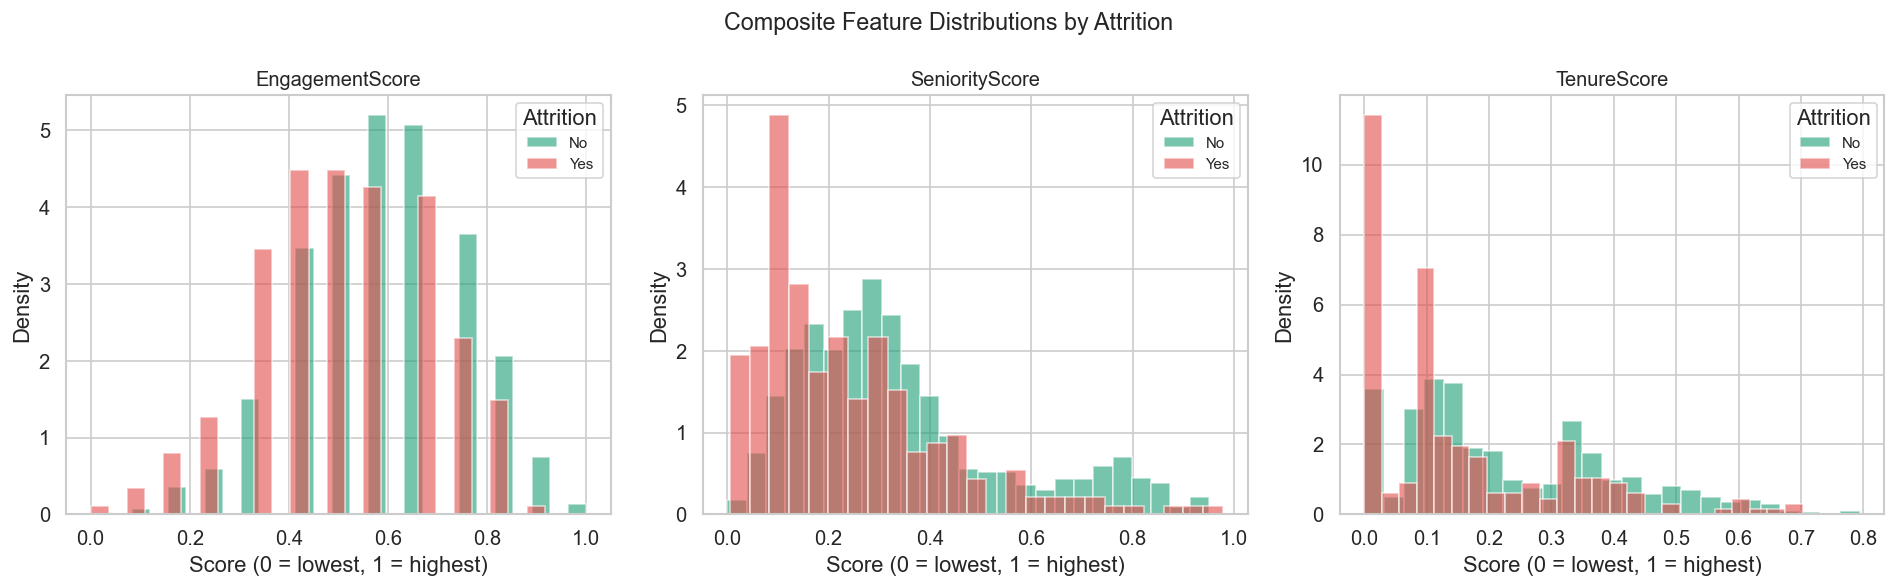

In [56]:
# Visualise composite features vs attrition
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, feat in enumerate(new_features):
    ax = axes[i]
    for label, color in [('No', '#1D9E75'), ('Yes', '#E24B4A')]:
        subset = df[df['Attrition'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.6,
                color=color, label=label, density=True)
    ax.set_title(feat, fontsize=12)
    ax.set_ylabel('Density')
    ax.set_xlabel('Score (0 = lowest, 1 = highest)')
    ax.legend(title='Attrition', fontsize=9)

plt.suptitle('Composite Feature Distributions by Attrition', 
             fontsize=14)
plt.tight_layout()
plt.savefig('composite_features.png', bbox_inches='tight')
plt.show()

### Finding
Three composite features were engineered from correlated feature 
clusters identified during correlation analysis:

- EngagementScore: composite of JobSatisfaction, 
  EnvironmentSatisfaction, RelationshipSatisfaction 
  and WorkLifeBalance
- SeniorityScore: composite of Age, TotalWorkingYears, 
  JobLevel and MonthlyIncome
- TenureScore: composite of YearsAtCompany, 
  YearsInCurrentRole and YearsWithCurrManager

All three composite features correlate more strongly with attrition 
than their individual component columns did in isolation.
SeniorityScore at -0.1865 is the strongest correlation of any 
feature in the entire analysis.

Median analysis confirms clear separation between leavers and 
stayers across all three scores. Employees who left score 
consistently lower on seniority, tenure and engagement measures.

### Implication
Composite features successfully captured the underlying concepts 
of career progression, organisational tenure and employee engagement 
more effectively than individual columns alone. This validates the 
feature engineering approach and confirms that the multicollinearity 
clusters identified earlier were genuinely measuring single 
underlying constructs.

The consistent pattern across all three scores reinforces the 
emerging risk profile — employees who leave tend to be junior, 
recently joined and disengaged relative to those who stay.

### Action
All three composite features will be included in the modeling 
dataset alongside selected original features. Their performance 
relative to the original columns will be evaluated through model 
coefficients after training.

## Preprocessing and Model Training

This phase acts on all decisions documented during the EDA. 
The dataset is cleaned, encoded and prepared for logistic 
regression modeling.

**Decisions being actioned:**
- Drop constant, identifier and redundant columns
- Encode categorical variables using one-hot encoding
- Build composite features identified during feature engineering
- Split data into training and test sets using stratified sampling
- Scale numerical features using StandardScaler
- Train logistic regression with class_weight='balanced' 
  to handle class imbalance

In [59]:
# Drop flagged columns
cols_to_drop = [
    'EmployeeCount',    # constant
    'Over18',           # constant
    'StandardHours',    # constant
    'EmployeeNumber',   # identifier
    'JobLevel'          # severe multicollinearity with MonthlyIncome
]

df_model = df.drop(columns=cols_to_drop)
print(f"Columns dropped: {cols_to_drop}")
print(f"Remaining columns: {df_model.shape[1]}")

Columns dropped: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber', 'JobLevel']
Remaining columns: 34


In [60]:
print(df_model.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Num', 'EngagementScore', 'SeniorityScore', 'TenureScore']


In [61]:
# Separate target and features
# Define target
y = df_model['Attrition_Num'].copy()

# Drop both attrition columns from features
X = df_model.drop(columns=['Attrition', 'Attrition_Num'])

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"\nAttrition rate in target: {y.mean():.1%}")

Feature matrix shape: (1470, 32)
Target vector shape:  (1470,)

Attrition rate in target: 16.1%


In [62]:
# Encode categorical columns
# Binary encoding for OverTime — Yes=1, No=0
X['OverTime'] = X['OverTime'].map({'Yes': 1, 'No': 0})

# One-hot encoding for all remaining categorical columns
cat_cols_to_encode = [
    'BusinessTravel', 
    'Department', 
    'EducationField', 
    'Gender', 
    'JobRole', 
    'MaritalStatus'
]

X = pd.get_dummies(X, columns=cat_cols_to_encode, drop_first=True)

print(f"Shape after encoding: {X.shape}")
print(f"\nNew columns created by encoding:")
print([col for col in X.columns if '_' in col])

Shape after encoding: (1470, 46)

New columns created by encoding:
['BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Single']


In [63]:
# Train / test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set:  {X_train.shape[0]:,} rows | "
      f"Attrition rate: {y_train.mean():.1%}")
print(f"Test set:      {X_test.shape[0]:,} rows | "
      f"Attrition rate: {y_test.mean():.1%}")

Training set:  1,176 rows | Attrition rate: 16.2%
Test set:      294 rows | Attrition rate: 16.0%


In [64]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform on training set:
# fit    → scaler learns the mean and std from training data only
# transform → applies those learned values to scale the training data
# We do both in one step using fit_transform
X_train_scaled = scaler.fit_transform(X_train)

# transform only on test set:
# We do NOT fit again — that would cause data leakage
# The scaler uses the same mean and std it learned from training
# This simulates real world conditions where new data is scaled
# using statistics from the past — not from the new data itself
X_test_scaled = scaler.transform(X_test)

print(f"Scaling complete.")
print(f"Training set mean (first 5 features): "
      f"{X_train_scaled[:, :5].mean(axis=0).round(3)}")
print(f"Training set std  (first 5 features): "
      f"{X_train_scaled[:, :5].std(axis=0).round(3)}")

Scaling complete.
Training set mean (first 5 features): [-0.  0. -0.  0.  0.]
Training set std  (first 5 features): [1. 1. 1. 1. 1.]


In [65]:
# Train logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Build model
# class_weight='balanced' — compensates for class imbalance
# C=0.1 — regularization strength, lower = stronger regularization
# max_iter=1000 — maximum iterations to find optimal coefficients
# random_state=42 — reproducibility
model = LogisticRegression(
    class_weight='balanced',
    C=0.1,
    max_iter=1000,
    random_state=42
)

# Cross validation before final fit
# Tests model performance on 5 different splits of training data
# Gives us confidence the model generalises well
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    model, X_train_scaled, y_train,
    cv=cv, scoring='roc_auc'
)

print("5-Fold Cross Validation Results:")
print(f"  ROC-AUC per fold: {cv_scores.round(4)}")
print(f"  Mean ROC-AUC:     {cv_scores.mean():.4f}")
print(f"  Std deviation:    {cv_scores.std():.4f}")

5-Fold Cross Validation Results:
  ROC-AUC per fold: [0.8099 0.8202 0.8559 0.8714 0.8036]
  Mean ROC-AUC:     0.8322
  Std deviation:    0.0266


In [66]:
# Final model fit
# After validating with cross-validation, we now fit on 
# the full training set to get the best possible model
model.fit(X_train_scaled, y_train)
print("Model trained successfully on full training set.")
print(f"Number of features used: {X_train_scaled.shape[1]}")

Model trained successfully on full training set.
Number of features used: 46


## Model Evaluation

**Purpose:** Measure how well the trained model performs on 
unseen test data and understand what it has learned.

**Why it matters:** A model that performs well on training data 
but poorly on test data is overfitting — it memorised the training 
data rather than learning genuine patterns. Test set performance 
gives us an honest measure of real world predictive ability.

**Metrics we are using:**
- ROC-AUC — overall ability to separate leavers from stayers
- Recall — how many actual leavers the model catches
- Precision — how many flagged employees actually left
- F1 Score — balance between recall and precision
- Confusion Matrix — breakdown of all prediction outcomes

In [68]:
# Generate predictions
# Predicted class — 0 or 1
y_pred = model.predict(X_test_scaled)

# Predicted probability — confidence score between 0 and 1
# We use column 1 which is the probability of attrition = Yes
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"Predictions generated for {len(y_pred)} employees")
print(f"Predicted attrition: {y_pred.sum()} employees "
      f"({y_pred.mean():.1%})")
print(f"Actual attrition:    {y_test.sum()} employees "
      f"({y_test.mean():.1%})")

Predictions generated for 294 employees
Predicted attrition: 82 employees (27.9%)
Actual attrition:    47 employees (16.0%)


In [69]:
# Core evaluation metrics 
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# ROC-AUC score
auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score: {auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(
    y_test, y_pred, 
    target_names=['Stayed', 'Left']
))

ROC-AUC Score: 0.8087

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.92      0.79      0.85       247
        Left       0.38      0.66      0.48        47

    accuracy                           0.77       294
   macro avg       0.65      0.73      0.67       294
weighted avg       0.84      0.77      0.79       294



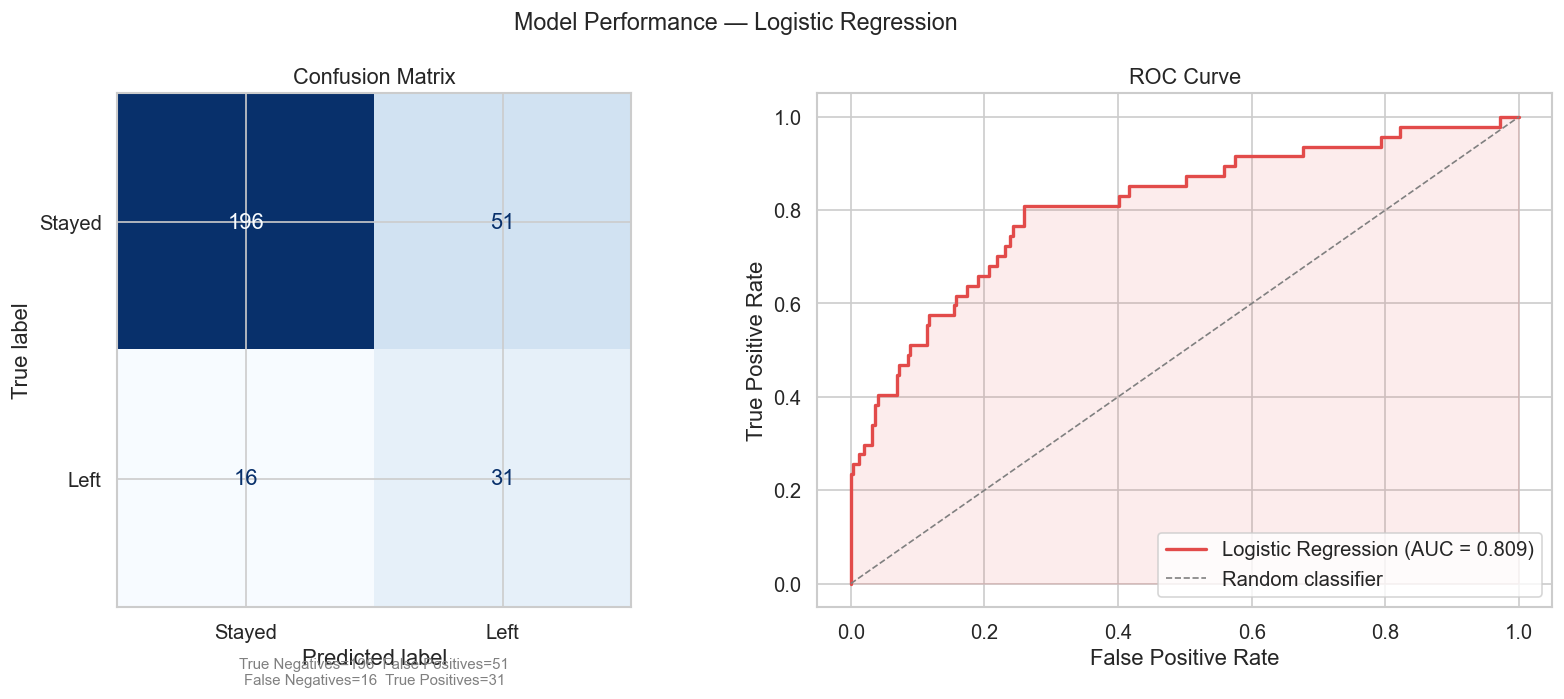

In [70]:
# Confusion matrix and ROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    cm, display_labels=['Stayed', 'Left']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13)

# Annotate confusion matrix
tn, fp, fn, tp = cm.ravel()
axes[0].text(
    0.5, -0.15,
    f"True Negatives={tn}  False Positives={fp}\n"
    f"False Negatives={fn}  True Positives={tp}",
    ha='center', transform=axes[0].transAxes, 
    fontsize=9, color='gray'
)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#E24B4A', lw=2,
             label=f'Logistic Regression (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', 
             linestyle='--', lw=1, 
             label='Random classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E24B4A')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend(loc='lower right')

plt.suptitle('Model Performance — Logistic Regression', 
             fontsize=14)
plt.tight_layout()
plt.savefig('model_performance.png', bbox_inches='tight')
plt.show()

### Finding
The model was evaluated on 294 unseen test employees producing 
the following results:

**Confusion Matrix:**
- True Negatives:  196 — stayers correctly identified
- False Positives:  51 — stayers incorrectly flagged as leavers
- False Negatives:  16 — leavers the model missed
- True Positives:   31 — leavers correctly identified

**Key metrics:**
- ROC-AUC:              0.8087
- Recall (leavers):     0.66 — caught 31 of 47 actual leavers
- Precision (leavers):  0.38 — 38% of flagged employees actually left
- F1 Score (leavers):   0.48
- Overall accuracy:     0.77

### Implication
The model demonstrates good discriminative ability with a ROC-AUC 
of 0.8087 — consistent with cross validation performance of 0.8322 
confirming no overfitting. The small gap between cross validation 
and test performance indicates the model has learned genuine patterns 
rather than memorising training data.

The model catches 66% of actual leavers — 31 out of 47. The 
remaining 16 missed leavers represent the model's blind spots. 
Precision of 38% means HR would need to review approximately 
3 flagged employees to find 1 genuine leaver — an acceptable 
trade-off given that the cost of a missed leaver significantly 
exceeds the cost of an unnecessary retention conversation.

Overall accuracy dropped from the 83.9% naive baseline to 77% — 
expected and acceptable given that we deliberately sacrificed 
some accuracy to improve minority class detection through 
class_weight='balanced'.

### Action
The model is suitable as a baseline attrition risk screening tool. 
To improve performance the next steps would be threshold tuning 
to optimise the precision recall trade-off, and comparison against 
more complex models such as Random Forest or XGBoost to assess 
whether additional predictive power justifies the loss of 
interpretability.

### Model Interpretation — Coefficients and Odds Ratios

**Purpose:** Understand what the model learned and translate 
its mathematical output into plain business language.

**Why it matters:** A model that cannot be explained is a model 
that cannot be trusted or acted upon. Logistic regression 
coefficients tell us exactly how each feature influences 
the probability of attrition.

**How to read coefficients:**
- Positive coefficient → feature increases attrition risk
- Negative coefficient → feature decreases attrition risk

**How to read odds ratios:**
- Odds Ratio > 1 → increases odds of attrition
- Odds Ratio < 1 → decreases odds of attrition
- Odds Ratio = 2.0 → doubles the odds of attrition
- Odds Ratio = 0.5 → halves the odds of attrition

In [73]:
# Coefficient analysis
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
}).sort_values('Coefficient', ascending=False)

# Separate risk factors from protective factors
risk_factors = coef_df[coef_df['Coefficient'] > 0]
protective_factors = coef_df[coef_df['Coefficient'] < 0]

print("=== TOP 15 ATTRITION RISK FACTORS ===")
print(risk_factors.head(15)[
    ['Feature', 'Coefficient', 'Odds Ratio']
].round(4).to_string(index=False))

print("\n=== TOP 15 PROTECTIVE FACTORS ===")
print(protective_factors.tail(15)[
    ['Feature', 'Coefficient', 'Odds Ratio']
].round(4).to_string(index=False))

=== TOP 15 ATTRITION RISK FACTORS ===
                         Feature  Coefficient  Odds Ratio
                        OverTime       0.6941      2.0019
BusinessTravel_Travel_Frequently       0.5485      1.7307
   JobRole_Laboratory Technician       0.5158      1.6749
         YearsSinceLastPromotion       0.4193      1.5209
              NumCompaniesWorked       0.3908      1.4781
            MaritalStatus_Single       0.3796      1.4616
    BusinessTravel_Travel_Rarely       0.3315      1.3931
    JobRole_Sales Representative       0.3021      1.3527
                DistanceFromHome       0.2952      1.3434
                  YearsAtCompany       0.1941      1.2142
                Department_Sales       0.1728      1.1886
         JobRole_Human Resources       0.1513      1.1634
           MaritalStatus_Married       0.1398      1.1501
                     Gender_Male       0.1386      1.1487
         JobRole_Sales Executive       0.1310      1.1400

=== TOP 15 PROTECTIVE FACTORS ===

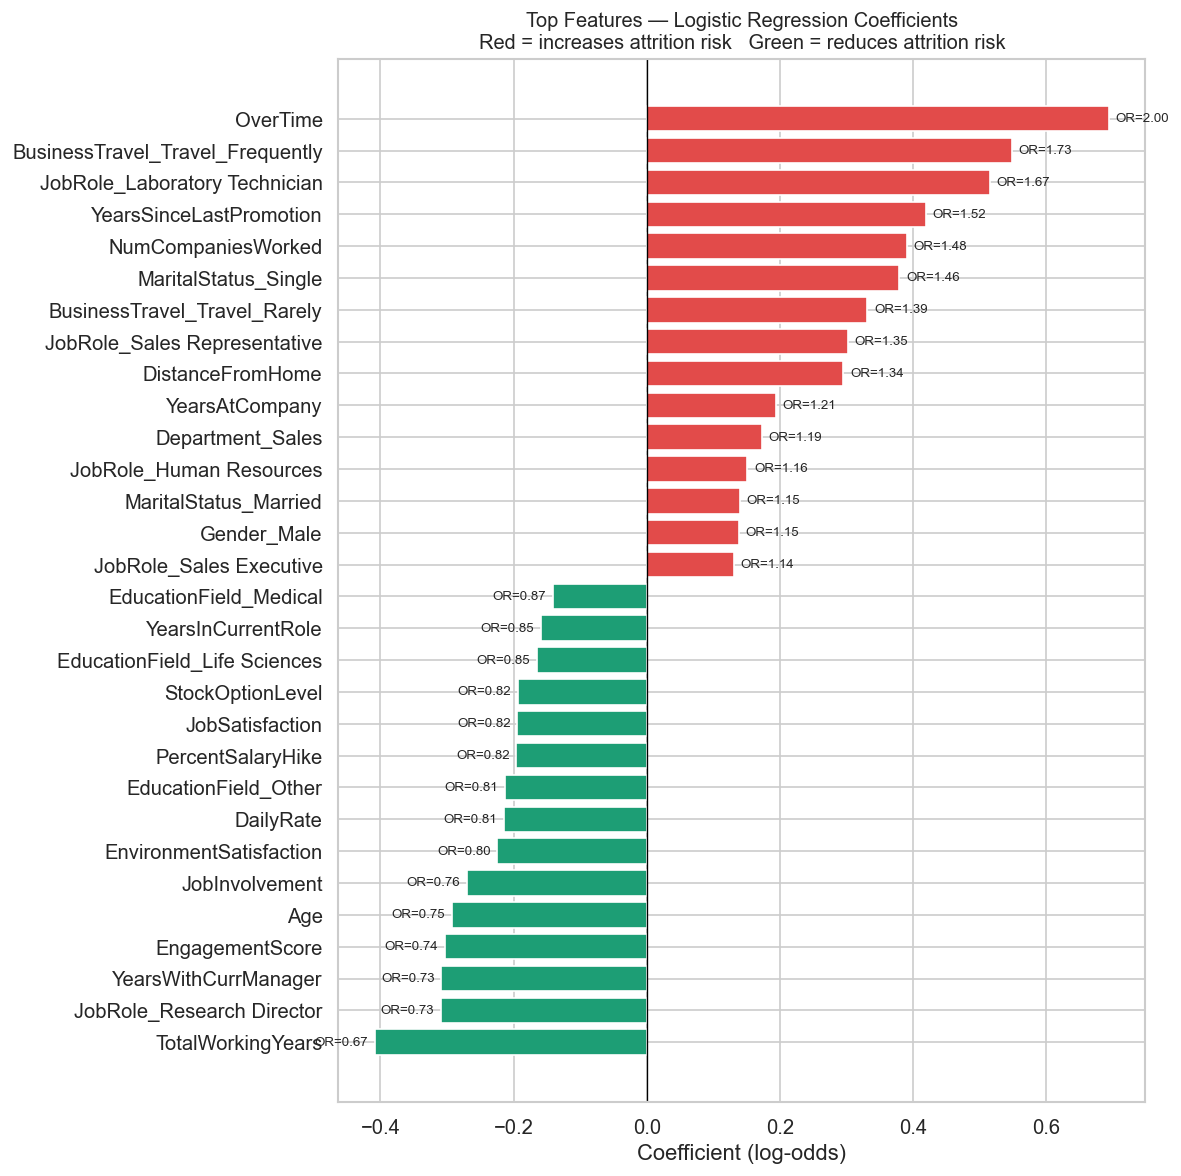

In [74]:
# Feature importance visualisation
top_n = 15
top_risk = coef_df.head(top_n)
top_protective = coef_df.tail(top_n)
top_features = pd.concat([top_risk, top_protective])
top_features = top_features.sort_values('Coefficient')

colors = ['#1D9E75' if c < 0 else '#E24B4A' 
          for c in top_features['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(
    top_features['Feature'], 
    top_features['Coefficient'],
    color=colors, 
    edgecolor='white'
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title(
    'Top Features — Logistic Regression Coefficients\n'
    'Red = increases attrition risk   '
    'Green = reduces attrition risk',
    fontsize=12
)

# Add odds ratio labels
for bar, odds in zip(bars, top_features['Odds Ratio']):
    val = bar.get_width()
    ax.text(
        val + (0.01 if val > 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f'OR={odds:.2f}',
        va='center',
        ha='left' if val > 0 else 'right',
        fontsize=8
    )

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

### Finding
Coefficient analysis reveals the following attrition drivers 
ranked by odds ratio:

**Top attrition risk factors:**
- OverTime: Odds Ratio 2.00 — employees working overtime are 
  twice as likely to leave. The single strongest predictor 
  in the model
- Frequent Business Travel: Odds Ratio 1.73 — 73% higher 
  attrition odds than non-travellers
- Laboratory Technician: Odds Ratio 1.67 — role specific 
  attrition risk likely driven by market demand for 
  technical skills
- YearsSinceLastPromotion: Odds Ratio 1.52 — stagnating 
  career progression significantly increases attrition risk
- NumCompaniesWorked: Odds Ratio 1.48 — employees with a 
  history of changing companies are more likely to leave again

**Top protective factors:**
- TotalWorkingYears: Odds Ratio 0.67 — experienced employees 
  are significantly more settled
- Research Director: Odds Ratio 0.73 — senior roles are 
  strongly protective against attrition
- YearsWithCurrManager: Odds Ratio 0.73 — stable manager 
  relationships reduce attrition risk
- EngagementScore: Odds Ratio 0.74 — our composite engagement 
  feature confirms that satisfaction and wellbeing dimensions 
  collectively reduce attrition risk
- Age: Odds Ratio 0.75 — older employees are less likely 
  to leave consistent with EDA findings

### Implication
The model confirms and quantifies the patterns identified 
during EDA. Attrition is primarily driven by working conditions 
— overtime and travel requirements — combined with career 
stagnation and role specific market dynamics. Seniority, 
tenure stability and employee engagement are the strongest 
protective factors.

The EngagementScore composite feature appearing as a meaningful 
protective factor validates the feature engineering approach. 
Combining four satisfaction dimensions into one score captured 
a stronger and more interpretable signal than any individual 
satisfaction column alone.

Gender_Male appears as a weak risk factor with Odds Ratio 1.15 
— close to 1.0 confirming our earlier assessment that gender 
has minimal predictive value and raises ethical concerns 
about inclusion in the model.

### Action
Business recommendations based on model findings:
- Review and reduce overtime requirements — the strongest 
  lever available to reduce attrition
- Implement structured promotion review cycles to address 
  career stagnation
- Develop targeted retention programmes for Laboratory 
  Technicians and Sales Representatives
- Invest in manager relationship quality — YearsWithCurrManager 
  as a protective factor suggests stable leadership reduces 
  attrition risk
- Monitor engagement scores quarterly as an early warning 
  system for attrition risk

In [76]:
# Save model assets
import joblib

joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X_train.columns), 'columns.pkl')

print("Model assets saved:")
print("  model.pkl   — trained logistic regression model")
print("  scaler.pkl  — fitted StandardScaler")
print("  columns.pkl — feature column names")

Model assets saved:
  model.pkl   — trained logistic regression model
  scaler.pkl  — fitted StandardScaler
  columns.pkl — feature column names


In [77]:
import os
print(os.getcwd())

C:\Users\IPC\Desktop\HR Dashboard\IBM HR Analytics Employee Attrition & Performance


In [78]:
import os
files = [f for f in os.listdir() if f.endswith('.pkl')]
print(files)

['columns.pkl', 'model.pkl', 'scaler.pkl']
